# Causal Feature Engineering and Leakage Control

**Master's Thesis in Data Science - Chapter 5.3: the predictor layer**

Chapter 4 (notebook `01`) described *what the market looks like*. This notebook describes *what the
model is allowed to know, and when*. It is the bridge between a descriptive dataset and a predictive
experiment, and it is the single place where the most expensive mistake in quantitative research is
either prevented or committed: **look-ahead bias**.

The notebook is deliberately *analytically deep but technically thin*. Every builder, contract and
validation routine lives in tested modules under `src/perp_lab/features/`; this notebook resolves the
configured feature set, exercises the guarantees empirically, and interprets the result.

## 1. Executive summary

**Objective.** Demonstrate - not merely assert - that every predictor used downstream is computable
from information available at or before its own bar's close, quantify the cost of that restriction
(warm-up, nulls, redundancy), and show experimentally what happens when the restriction is dropped.

**Why this matters more than model choice.** A feature that peeks a few bars into the future will beat
any honest model. Backtests built on leaked features do not fail loudly; they produce results far too
good to be true, which are then rationalised rather than audited. Section 6 reproduces that failure
mode on real BTC data with a single deliberately non-causal feature, and measures the size of the
illusion in Sharpe points.

**What is verified here.**

| # | Guarantee | How it is tested |
|---|-----------|------------------|
| G1 | **Prefix invariance** - appending future bars never changes a past feature value | Rebuild on a truncated frame; compare element-wise |
| G2 | **Future-mutation invariance** - corrupting future rows never changes past values | Overwrite the tail with noise; rebuild; compare |
| G3 | **Declared warm-up is exact** - the contract's `warmup` equals the observed leading nulls | Count leading nulls per column |
| G4 | **Shift applied exactly once** - contextual features are lagged, and only once | Compare against a manually lagged reference |
| G5 | **No infinities** - guarded denominators map to null, never to `+/-inf` | Scan every column |
| G6 | **Determinism** - rebuilding twice is bit-for-bit identical | Rebuild and compare frame equality |
| G7 | **Holdout isolation** - the frozen holdout is never read | `assert_no_holdout` gate on load and on build |

**Temporal separation (mandatory).** Development window `2020-01-01 00:00 UTC` .. `2025-12-31 23:00
UTC` (1h bars). Frozen holdout `[2026-01-01 00:00 UTC, 2026-07-01 00:00 UTC)`. **No holdout
observation is loaded, built into a feature, plotted or used to compute any statistic.**

### Research questions

- **RQ1.** Does the feature contract describe each predictor precisely enough to be audited without
  reading its implementation?
- **RQ2.** Are the causality guarantees G1-G7 satisfied empirically on real BTC/ETH data, not just in
  unit tests on synthetic fixtures?
- **RQ3.** How large is the *illusory* performance produced by a single non-causal feature, measured
  on the same bars, the same rule and the same cost model - and is its sign even meaningful when
  direction is a searchable parameter?
- **RQ4.** How much genuinely independent information does the feature set carry, once redundancy is
  accounted for?
- **RQ5.** Are feature distributions stable enough across years and volatility regimes that a model
  fitted on early folds remains calibrated on later ones?
- **RQ6.** Are contextual features (cross-asset, funding) joined without importing future information?

## 2. Configuration, data loading and holdout gates

**Analytical question.** What exactly is being built, from which bars, and can we guarantee the
holdout is untouched? **Method.** All configuration comes from the versioned contracts
(`configs/data_contract.yaml`, `configs/experiment.yaml`); bars are read through the holdout-safe
`DataLake`, which filters the development partition on load and then asserts that no timestamp
reaches the holdout boundary. **Interpretation.** If the gates pass, every number below this cell is
computed strictly on development data.

In [1]:
# Locate the repository root and make src/ importable, so the notebook runs
# unchanged from the repository root or from the notebooks/ directory.
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
REPO_ROOT = _root
print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy
from IPython.display import display
from scipy.cluster import hierarchy as sch

from perp_lab import __version__ as perp_lab_version
from perp_lab.backtesting import run_backtest
from perp_lab.config import Paths, load_data_contract, load_experiment_config, load_settings
from perp_lab.eda import DataLake
from perp_lab.eda.datasets import assert_no_holdout
from perp_lab.features import (
    FeatureContext,
    build_feature_frame,
    build_feature_manifest,
    build_predictor_rows,
    feature_columns,
    resolve_feature_set,
)
from perp_lab.features import spec as fspec
from perp_lab.reporting import (
    ArtifactContext,
    apply_house_style,
    asset_color,
    save_figure,
    save_table,
)

apply_house_style()

SETTINGS = load_settings()
SEED = SETTINGS.seed
np.random.seed(SEED)

CONTRACT = load_data_contract()
EXP = load_experiment_config()
PATHS = Paths()
LAKE = DataLake(CONTRACT, PATHS)

SYMBOLS = list(CONTRACT.symbol_names())
PRIMARY_TF = EXP.timeframes.primary
HOLDOUT_START = LAKE.holdout_start
DAYS_PER_YEAR = EXP.annualization_days
FIG_DPI = 300

print("Environment")
print(f"  Python      : {platform.python_version()} ({sys.platform})")
print(f"  perp_lab    : {perp_lab_version}")
print(f"  polars      : {pl.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")
print(f"  matplotlib  : {matplotlib.__version__}")
print(f"  random seed : {SEED}")
print("Experiment contract")
print(f"  version         : {EXP.version}")
print(f"  assets          : {SYMBOLS}")
print(f"  primary tf      : {PRIMARY_TF}")
print(f"  feature impl    : {fspec.IMPL_VERSION}")
print(f"  holdout start   : {HOLDOUT_START.isoformat()}  (frozen; never read here)")
print(f"  annualisation   : {DAYS_PER_YEAR} days (24/7)")

Environment
  Python      : 3.12.3 (win32)
  perp_lab    : 0.1.0
  polars      : 1.43.1 | numpy 2.5.1 | scipy 1.18.0
  matplotlib  : 3.11.1
  random seed : 42
Experiment contract
  version         : 0.1.0
  assets          : ['BTCUSDT', 'ETHUSDT']
  primary tf      : 1h
  feature impl    : 0.3.0
  holdout start   : 2026-01-01T00:00:00+00:00  (frozen; never read here)
  annualisation   : 365 days (24/7)


In [3]:
# --- Artifact export context (figures/tables + reproducibility sidecars) -----
NB_ID = "02_causal_features_and_leakage"
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "features",
    tables_dir=PATHS.reports_root / "tables" / "features",
    metadata_dir=PATHS.reports_root / "metadata" / "features",
    config={
        "seed": SEED,
        "contract_version": CONTRACT.version,
        "experiment_version": EXP.version,
        "feature_impl_version": fspec.IMPL_VERSION,
        "primary_timeframe": PRIMARY_TF,
        "holdout_start": HOLDOUT_START.isoformat(),
        "days_per_year": DAYS_PER_YEAR,
    },
    repo_root=".",
)


def show(fig, name, caption=""):
    # Save a figure (PNG + vector PDF + metadata sidecar), embed it, then close it.
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


# --- Load DEVELOPMENT partitions only ----------------------------------------
BARS: dict[str, pl.DataFrame] = {}
FUND: dict[str, pl.DataFrame] = {}
load_rows: list[dict] = []
for sym in SYMBOLS:
    ds = LAKE.load_klines(sym, PRIMARY_TF, partition="development")
    BARS[sym] = ds.frame
    ctx.datasets[ds.dataset_id] = ds.sha256 or ""
    load_rows.append(
        {
            "dataset_id": ds.dataset_id,
            "rows": ds.n_rows,
            "start": str(ds.period_start),
            "end": str(ds.period_end),
            "sha256_12": (ds.sha256 or "")[:12],
            "holdout_excluded": ds.holdout_excluded,
        }
    )
    fds = LAKE.load_funding(sym, partition="development")
    FUND[sym] = fds.frame
    ctx.datasets[fds.dataset_id] = fds.sha256 or ""
    load_rows.append(
        {
            "dataset_id": fds.dataset_id,
            "rows": fds.n_rows,
            "start": str(fds.period_start),
            "end": str(fds.period_end),
            "sha256_12": (fds.sha256 or "")[:12],
            "holdout_excluded": fds.holdout_excluded,
        }
    )

# --- Gate 1: hard holdout assertion on every loaded frame --------------------
for sym in SYMBOLS:
    assert_no_holdout(BARS[sym], HOLDOUT_START, time_col="open_time")
    assert_no_holdout(FUND[sym], HOLDOUT_START, time_col="funding_time")

DEV_START = BARS[SYMBOLS[0]].select(pl.col("open_time").min()).item()
DEV_END = BARS[SYMBOLS[0]].select(pl.col("open_time").max()).item()
ctx.period = f"{DEV_START} .. {DEV_END} (development, holdout excluded)"

display(pl.DataFrame(load_rows))
print(f"\nDevelopment span ({PRIMARY_TF}): {DEV_START}  ..  {DEV_END}")
print(
    "HOLDOUT GATE: PASSED - no observation at or after "
    f"{HOLDOUT_START.isoformat()} is present in any loaded frame."
)

dataset_id,rows,start,end,sha256_12,holdout_excluded
str,i64,str,str,str,bool
"""binance_um_BTCUSDT_klines_1h_d…",52608,"""2020-01-01 00:00:00+00:00""","""2025-12-31 23:00:00+00:00""","""49250896a17b""",true
"""binance_um_BTCUSDT_fundingRate""",6576,"""2020-01-01 00:00:00+00:00""","""2025-12-31 16:00:00.001000+00:…","""a85942930e58""",true
"""binance_um_ETHUSDT_klines_1h_d…",52608,"""2020-01-01 00:00:00+00:00""","""2025-12-31 23:00:00+00:00""","""8c2b03db26c6""",true
"""binance_um_ETHUSDT_fundingRate""",6576,"""2020-01-01 00:00:00+00:00""","""2025-12-31 16:00:00.001000+00:…","""8168dc2f7004""",true



Development span (1h): 2020-01-01 00:00:00+00:00  ..  2025-12-31 23:00:00+00:00
HOLDOUT GATE: PASSED - no observation at or after 2026-01-01T00:00:00+00:00 is present in any loaded frame.


## 3. The feature contract: a registry, not a pile of functions

**Analytical question.** Can a reviewer audit what a predictor knows without reading its code?
**Method.** Every feature *kind* is registered in `perp_lab.features.spec.KIND_REGISTRY` as a
`KindDef` that declares its family, required inputs, availability (the instant at which its value is
knowable), leakage risk, downstream consumers, null and infinity policies, whether it is a **proxy**
for an unobserved quantity, and which **pack** it belongs to.

Two design decisions in that registry deserve emphasis, because both are overfitting controls rather
than software conveniences:

1. **Packs (`core` / `extended` / `experimental`).** A run declares which packs it may use. Anything
   outside them is not merely unused - it is *unavailable*. This is the primary defence against
   searching a space so wide that some parameterisation is bound to look good by chance.
2. **Proxy flags.** Features that approximate a quantity we cannot observe (liquidity without an
   order book, basis without an index feed) are marked `is_proxy` and must never be reported as
   measured. Labelling a proxy honestly is what keeps the interpretation of a result defensible.

**Interpretation.** The registry turns "trust me, it's causal" into a machine-readable claim that the
rest of this notebook falsifies or confirms.

In [4]:
CATALOGUE = pl.DataFrame(fspec.catalogue())
COUNTS = fspec.catalogue_counts()
PROXIES = fspec.proxy_kinds()

cat_view = CATALOGUE.select(
    "kind",
    "family",
    "pack",
    "availability",
    "parameterised",
    "requires_context",
    "is_proxy",
    "leakage_risk",
)
save_table(
    cat_view,
    "t01_feature_kind_catalogue",
    ctx,
    caption="Complete registry of feature kinds with family, pack, availability and leakage risk.",
)
display(cat_view)

print(f"Registered kinds : {COUNTS['total_kinds']['kinds']}")
print(f"By pack          : {COUNTS['by_pack']}")
print(f"By family        : {COUNTS['by_family']}")
print(f"Declared proxies : {list(PROXIES)}")

kind,family,pack,availability,parameterised,requires_context,is_proxy,leakage_risk
str,str,str,str,bool,bool,bool,str
"""atr""","""volatility""","""core""","""close t""",true,false,false,"""low (uses current bar range + …"
"""basis""","""derivatives""","""extended""","""close t (mark/index aligned to…",false,true,true,"""low (contemporaneous mark vs i…"
"""cum_return""","""returns""","""core""","""close t""",false,false,false,"""low (expanding sum of past log…"
"""dow_cyclical""","""time""","""extended""","""open t (known ex-ante)""",false,false,false,"""none (calendar clock, known in…"
"""ema""","""trend""","""core""","""close t""",true,false,false,"""low (recursive past-only mean)"""
…,…,…,…,…,…,…,…
"""volume_zscore""","""volume""","""extended""","""close t""",true,false,false,"""low (trailing mean/std; std=0 …"
"""xasset_corr""","""cross_asset""","""extended""","""close t (peer bar closes simul…",true,true,false,"""low (trailing correlation of p…"
"""xasset_rel_momentum""","""cross_asset""","""extended""","""close t (peer bar closes simul…",true,true,false,"""low (exact join; past-only mom…"


Registered kinds : 25
By pack          : {'core': 13, 'extended': 10, 'experimental': 2}
By family        : {'cross_asset': 3, 'derivatives': 3, 'mean_reversion': 1, 'momentum': 1, 'order_flow': 2, 'range': 2, 'returns': 2, 'time': 2, 'trend': 5, 'volatility': 2, 'volume': 2}
Declared proxies : ['basis', 'taker_buy_imbalance', 'taker_buy_ratio']


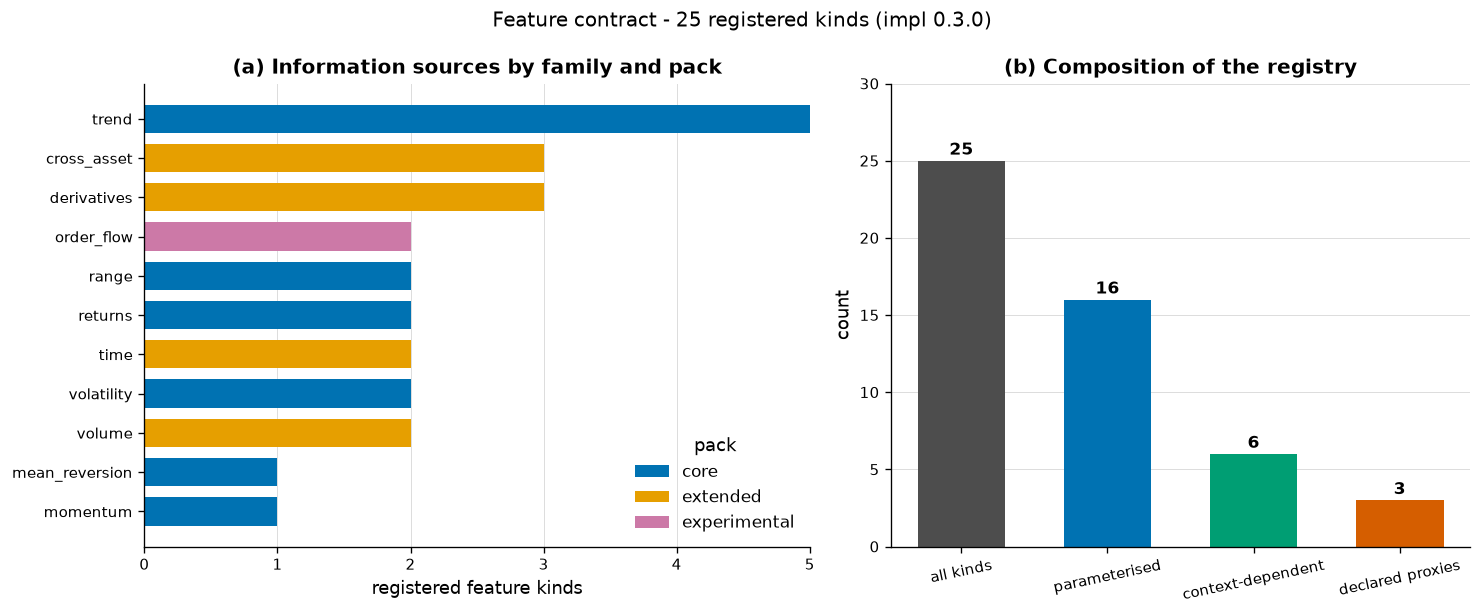

In [5]:
# --- F01: the registry as a family x pack map --------------------------------
PACK_ORDER = list(fspec.PACKS)
PACK_COLORS = {"core": "#0072B2", "extended": "#E69F00", "experimental": "#CC79A7"}

families = sorted(COUNTS["by_family"], key=lambda f: -COUNTS["by_family"][f])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 5.2), gridspec_kw={"width_ratios": [1.15, 1.0]})

# Left: stacked kinds per family, coloured by pack.
base = np.zeros(len(families))
for pack in PACK_ORDER:
    vals = np.array(
        [
            CATALOGUE.filter((pl.col("family") == f) & (pl.col("pack") == pack)).height
            for f in families
        ],
        dtype=float,
    )
    axL.barh(families, vals, left=base, color=PACK_COLORS[pack], label=pack, height=0.72)
    base += vals
axL.invert_yaxis()
axL.set_xlabel("registered feature kinds")
axL.set_title("(a) Information sources by family and pack")
axL.legend(title="pack", loc="lower right")
axL.grid(axis="y", visible=False)

# Right: kinds vs the columns they can generate, plus proxy/context annotations.
n_kinds = COUNTS["total_kinds"]["kinds"]
n_param = int(CATALOGUE.select(pl.col("parameterised").sum()).item())
n_ctx = int(CATALOGUE.select(pl.col("requires_context").sum()).item())
n_proxy = len(PROXIES)
bars_x = ["all kinds", "parameterised", "context-dependent", "declared proxies"]
bars_y = [n_kinds, n_param, n_ctx, n_proxy]
cols = ["#4D4D4D", "#0072B2", "#009E73", "#D55E00"]
axR.bar(bars_x, bars_y, color=cols, width=0.6)
for x, y in zip(bars_x, bars_y, strict=True):
    axR.text(x, y + 0.4, str(y), ha="center", fontsize=10, fontweight="bold")
axR.set_ylabel("count")
axR.set_ylim(0, max(bars_y) * 1.2)
axR.set_title("(b) Composition of the registry")
axR.tick_params(axis="x", rotation=12)
axR.grid(axis="x", visible=False)

fig.suptitle(
    f"Feature contract - {n_kinds} registered kinds (impl {fspec.IMPL_VERSION})", fontsize=12
)
fig.tight_layout()
show(
    fig,
    "g01_feature_registry_map",
    caption="The feature registry: kinds grouped by family and pack (a), and the composition of the "
    "registry by parameterisation, context dependency and proxy status (b).",
)

**Interpretation (3.1).** The registry counts *information sources*, not columns. This distinction is
not pedantry: one parameterised kind such as `sma` can emit dozens of columns, and reporting the
column count as though it were the number of independent signals would overstate the breadth of the
study by an order of magnitude - exactly the inflation that makes multiple-testing corrections
meaningless. The `core` pack is intentionally small and dominated by price-derived trend and
volatility measures; `extended` adds cross-asset and derivatives context; `experimental` holds the
kinds whose input quality we cannot fully vouch for. The declared proxies are the honest admission
that this study has no order-book data: what is labelled a liquidity or order-flow measure is an
approximation computed from aggregated taker volume, and every downstream claim inherits that caveat.

## 4. The operational feature set and its warm-up cost

**Analytical question.** Which concrete columns does the configured experiment build, and what does
causality cost in usable observations? **Method.** `resolve_feature_set` validates and de-duplicates
the items listed in `configs/experiment.yaml`, then `build_feature_frame` computes them in a
deterministic order. Each resolved `FeatureSpec` declares a `warmup`: the number of leading rows that
*must* be null because a trailing window of that length does not yet exist. We compare the declared
warm-up against the observed count of leading nulls, per column and per asset.

**Interpretation.** Warm-up is the visible price of refusing to look ahead. A centred window would
have no warm-up at all - which is precisely why its absence is a symptom, not a feature.

In [6]:
SPECS = resolve_feature_set(EXP.features.feature_set, ensure_sma=())
FEATURE_COLS = feature_columns(SPECS)

spec_rows = []
for s in SPECS:
    spec_rows.append(
        {
            "name": s.name,
            "kind": s.kind,
            "family": s.family,
            "columns": ", ".join(s.columns),
            "params": ", ".join(f"{k}={v}" for k, v in s.params.items()) or "-",
            "availability": s.availability,
            "shift": s.shift,
            "warmup": s.warmup,
            "lookback": s.lookback,
            "pack": s.pack,
            "proxy": s.is_proxy,
        }
    )
SPEC_TABLE = pl.DataFrame(spec_rows)
save_table(
    SPEC_TABLE,
    "t02_operational_feature_set",
    ctx,
    caption="The resolved feature set built by the development pipeline, with declared "
    "availability, shift and warm-up.",
)
display(SPEC_TABLE)
print(f"{len(SPECS)} specs -> {len(FEATURE_COLS)} columns: {FEATURE_COLS}")

name,kind,family,columns,params,availability,shift,warmup,lookback,pack,proxy
str,str,str,str,str,str,i64,i64,i64,str,bool
"""log_return""","""log_return""","""returns""","""log_return""","""-""","""close t""",0,1,1,"""core""",false
"""momentum_12""","""momentum""","""momentum""","""momentum_12""","""window=12""","""close t""",0,12,12,"""core""",false
"""momentum_24""","""momentum""","""momentum""","""momentum_24""","""window=24""","""close t""",0,24,24,"""core""",false
"""sma_24""","""sma""","""trend""","""sma_24""","""window=24""","""close t""",0,23,24,"""core""",false
"""sma_96""","""sma""","""trend""","""sma_96""","""window=96""","""close t""",0,95,96,"""core""",false
…,…,…,…,…,…,…,…,…,…,…
"""atr_14""","""atr""","""volatility""","""atr_14""","""window=14""","""close t""",0,13,14,"""core""",false
"""range_norm""","""range_norm""","""range""","""range_norm""","""-""","""close t""",0,0,1,"""core""",false
"""rel_volume_24""","""rel_volume""","""volume""","""rel_volume_24""","""window=24""","""close t""",0,23,24,"""extended""",false


13 specs -> 14 columns: ['log_return', 'momentum_12', 'momentum_24', 'sma_24', 'sma_96', 'price_dist_sma_48', 'zscore_48', 'rvol_96', 'atr_14', 'range_norm', 'rel_volume_24', 'hour_sin', 'hour_cos', 'taker_buy_imbalance']


In [7]:
# --- Build the feature frames (holdout guard re-applied inside the builder) --
FEAT: dict[str, pl.DataFrame] = {}
for sym in SYMBOLS:
    frame, _ = build_feature_frame(BARS[sym], SPECS, holdout_start=HOLDOUT_START)
    FEAT[sym] = frame
    assert_no_holdout(frame, HOLDOUT_START, time_col="open_time")


# --- G3: declared warm-up vs observed leading nulls --------------------------
def leading_nulls(series: pl.Series) -> int:
    mask = series.is_null().to_numpy()
    if not mask.any():
        return 0
    first_valid = int(np.argmin(mask)) if (~mask).any() else int(mask.size)
    return first_valid


warm_rows = []
for sym in SYMBOLS:
    frame = FEAT[sym]
    for s in SPECS:
        for col in s.columns:
            warm_rows.append(
                {
                    "symbol": sym,
                    "column": col,
                    "declared_warmup": s.warmup,
                    "observed_leading_nulls": leading_nulls(frame[col]),
                    "total_nulls": int(frame[col].null_count()),
                }
            )
WARMUP = pl.DataFrame(warm_rows).with_columns(
    (pl.col("observed_leading_nulls") - pl.col("declared_warmup")).alias("delta"),
    (pl.col("total_nulls") - pl.col("observed_leading_nulls")).alias("interior_nulls"),
)
save_table(
    WARMUP,
    "t03_warmup_declared_vs_observed",
    ctx,
    caption="Declared warm-up versus observed leading nulls for every built column (G3).",
)
display(WARMUP)

WARMUP_EXACT = bool((WARMUP["delta"] == 0).all())
print(f"\nG3 declared warm-up == observed leading nulls : {'PASS' if WARMUP_EXACT else 'FAIL'}")
print(
    f"Rows per asset after the longest warm-up      : "
    f"{FEAT[SYMBOLS[0]].height - int(WARMUP['declared_warmup'].max())}"
)

symbol,column,declared_warmup,observed_leading_nulls,total_nulls,delta,interior_nulls
str,str,i64,i64,i64,i64,i64
"""BTCUSDT""","""log_return""",1,1,1,0,0
"""BTCUSDT""","""momentum_12""",12,12,12,0,0
"""BTCUSDT""","""momentum_24""",24,24,24,0,0
"""BTCUSDT""","""sma_24""",23,23,23,0,0
"""BTCUSDT""","""sma_96""",95,95,95,0,0
…,…,…,…,…,…,…
"""ETHUSDT""","""range_norm""",0,0,0,0,0
"""ETHUSDT""","""rel_volume_24""",23,23,23,0,0
"""ETHUSDT""","""hour_sin""",0,0,0,0,0



G3 declared warm-up == observed leading nulls : PASS
Rows per asset after the longest warm-up      : 52512


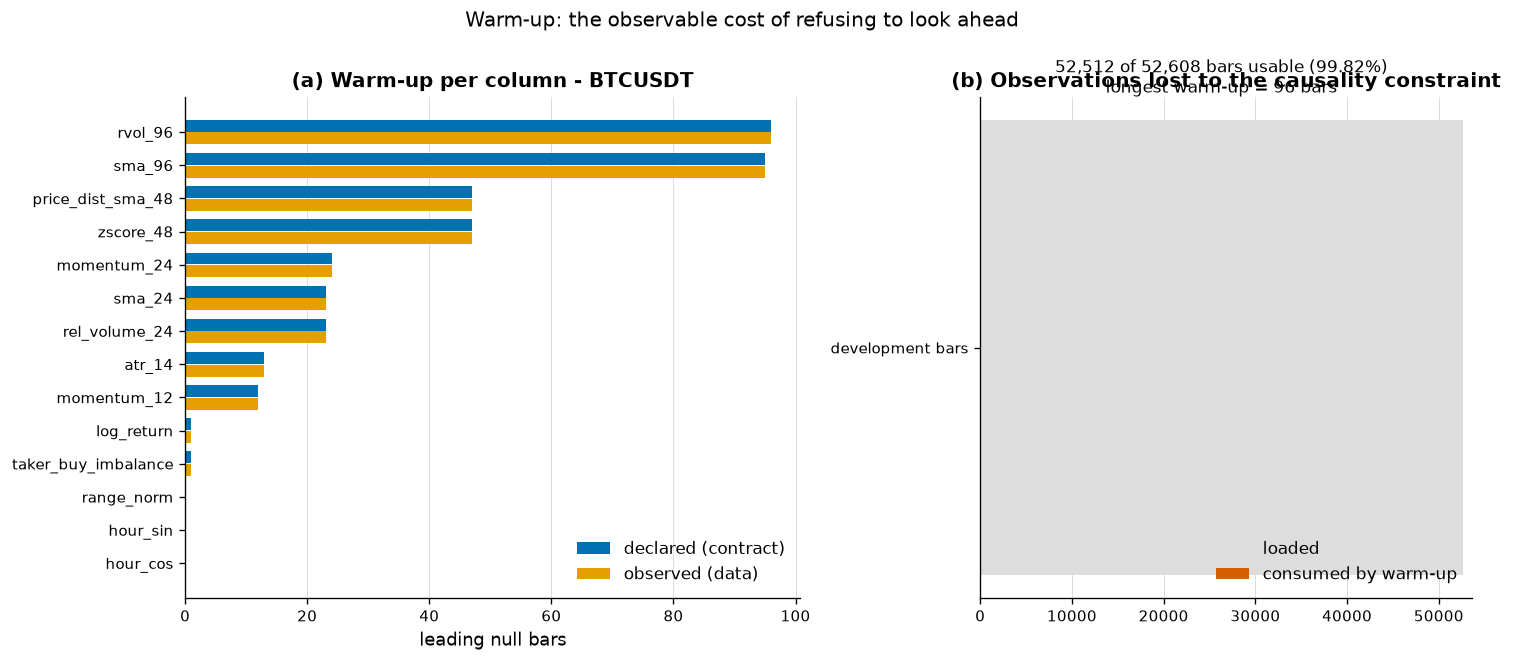

In [8]:
# --- F02: the warm-up cost of causality --------------------------------------
sym0 = SYMBOLS[0]
w0 = WARMUP.filter(pl.col("symbol") == sym0).sort("declared_warmup", descending=True)
cols = w0["column"].to_list()
declared = w0["declared_warmup"].to_numpy()
observed = w0["observed_leading_nulls"].to_numpy()
n_rows = FEAT[sym0].height

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12.5, 5.6), gridspec_kw={"width_ratios": [1.25, 1.0]})
y = np.arange(len(cols))
axA.barh(y - 0.19, declared, height=0.36, color="#0072B2", label="declared (contract)")
axA.barh(y + 0.19, observed, height=0.36, color="#E69F00", label="observed (data)")
axA.set_yticks(y)
axA.set_yticklabels(cols, fontsize=9)
axA.invert_yaxis()
axA.set_xlabel("leading null bars")
axA.set_title(f"(a) Warm-up per column - {sym0}")
axA.legend(loc="lower right")
axA.grid(axis="y", visible=False)

max_warm = int(declared.max())
usable = n_rows - max_warm
axB.barh(["development bars"], [n_rows], color="#DDDDDD", height=0.5, label="loaded")
axB.barh(["development bars"], [max_warm], color="#D55E00", height=0.5, label="consumed by warm-up")
axB.set_xlim(0, n_rows * 1.02)
axB.set_title("(b) Observations lost to the causality constraint")
axB.legend(loc="lower right")
axB.grid(axis="y", visible=False)
axB.text(
    n_rows * 0.5,
    0.28,
    f"{usable:,} of {n_rows:,} bars usable ({100 * usable / n_rows:.2f}%)\n"
    f"longest warm-up = {max_warm} bars",
    ha="center",
    fontsize=10,
)

fig.suptitle("Warm-up: the observable cost of refusing to look ahead", fontsize=12)
fig.tight_layout()
show(
    fig,
    "g02_warmup_cost",
    caption="Declared versus observed warm-up per feature column (a) and the share of the "
    "development sample consumed by the longest trailing window (b).",
)

**Interpretation (4.1).** Every observed leading-null count matches its declared warm-up exactly, so
the contract is not documentation that drifted from the code - it is a testable claim that currently
holds (G3 passes). The economic reading of panel (b) is that the longest trailing window costs well
under one percent of the development sample, which is an inexpensive insurance premium against
look-ahead bias. It also sets a hard floor for fold geometry: no walk-forward training window may be
shorter than the longest warm-up, or the first fold would train on rows that are entirely null. That
constraint is enforced later, in the validation layer.

## 5. Causality guarantees, exercised on real data

**Analytical question.** Do the guarantees G1, G2, G4, G5 and G6 hold on the actual BTC/ETH history,
or only on the small synthetic fixtures used by the unit tests? **Method.** Four adversarial
rebuilds:

- **G1 prefix invariance.** Truncate the frame at a cut point, rebuild features on the prefix, and
  compare every value against the corresponding rows of the full build. If any feature reads forward,
  the values must differ.
- **G2 future-mutation invariance.** Replace all bars *after* the cut point with corrupted prices
  (multiplied by 3 and shuffled), rebuild, and compare the rows *before* the cut.
- **G4 shift exactly once.** Rebuild the contextual `taker_buy_imbalance` against a manually lagged
  reference; a double shift or a missing shift both fail.
- **G5/G6 numerical hygiene and determinism.** Scan for non-finite values and rebuild twice.

**Interpretation.** These are falsification attempts, not demonstrations. A passing result is only
meaningful because the same procedure would visibly fail on a leaky implementation - which Section 6
confirms by running it against one.

In [9]:
CUT = int(FEAT[SYMBOLS[0]].height * 0.70)
rng = np.random.default_rng(SEED)
checks: list[dict] = []

for sym in SYMBOLS:
    full = FEAT[sym]
    raw = BARS[sym]

    # --- G1: prefix invariance -----------------------------------------------
    prefix_raw = raw.head(CUT)
    prefix_feat, _ = build_feature_frame(prefix_raw, SPECS, holdout_start=HOLDOUT_START)
    g1_max = 0.0
    for col in FEATURE_COLS:
        a = full[col].head(CUT).to_numpy().astype(float)
        b = prefix_feat[col].to_numpy().astype(float)
        both = np.isfinite(a) & np.isfinite(b)
        mismatch_nulls = int((np.isnan(a) != np.isnan(b)).sum())
        diff = float(np.max(np.abs(a[both] - b[both]))) if both.any() else 0.0
        g1_max = max(g1_max, diff + mismatch_nulls)
    checks.append(
        {
            "symbol": sym,
            "guarantee": "G1 prefix invariance",
            "statistic": "max |full[:cut] - prefix|",
            "value": g1_max,
            "passes": g1_max == 0.0,
        }
    )

    # --- G2: future-mutation invariance --------------------------------------
    tail_n = raw.height - CUT
    noise = rng.permutation(raw["close"].tail(tail_n).to_numpy()) * 3.0
    corrupted = raw.with_columns(
        pl.when(pl.int_range(pl.len()) >= CUT)
        .then(pl.Series("c", np.concatenate([np.zeros(CUT), noise])))
        .otherwise(pl.col("close"))
        .alias("close")
    )
    corrupt_feat, _ = build_feature_frame(corrupted, SPECS, holdout_start=HOLDOUT_START)
    g2_max = 0.0
    for col in FEATURE_COLS:
        a = full[col].head(CUT).to_numpy().astype(float)
        b = corrupt_feat[col].head(CUT).to_numpy().astype(float)
        both = np.isfinite(a) & np.isfinite(b)
        mismatch_nulls = int((np.isnan(a) != np.isnan(b)).sum())
        diff = float(np.max(np.abs(a[both] - b[both]))) if both.any() else 0.0
        g2_max = max(g2_max, diff + mismatch_nulls)
    checks.append(
        {
            "symbol": sym,
            "guarantee": "G2 future-mutation invariance",
            "statistic": "max |clean[:cut] - corrupted[:cut]|",
            "value": g2_max,
            "passes": g2_max == 0.0,
        }
    )

    # --- G4: contextual shift applied exactly once ---------------------------
    lag = int(next(s.params["lag"] for s in SPECS if s.kind == "taker_buy_imbalance"))
    reference = raw.with_columns(
        (
            2.0
            * pl.when(pl.col("quote_volume") > 0)
            .then(pl.col("taker_buy_quote") / pl.col("quote_volume"))
            .otherwise(None)
            - 1.0
        ).alias("_unlagged")
    ).with_columns(pl.col("_unlagged").shift(lag).alias("_expected"))
    a = full["taker_buy_imbalance"].to_numpy().astype(float)
    b = reference["_expected"].to_numpy().astype(float)
    both = np.isfinite(a) & np.isfinite(b)
    g4 = float(np.max(np.abs(a[both] - b[both]))) if both.any() else 0.0
    checks.append(
        {
            "symbol": sym,
            "guarantee": f"G4 shift applied exactly once (lag={lag})",
            "statistic": "max |built - manually lagged|",
            "value": g4,
            "passes": g4 < 1e-12,
        }
    )

    # --- G5: no infinities ----------------------------------------------------
    n_inf = 0
    for col in FEATURE_COLS:
        v = full[col].to_numpy().astype(float)
        n_inf += int(np.isinf(v).sum())
    checks.append(
        {
            "symbol": sym,
            "guarantee": "G5 no infinities",
            "statistic": "count of +/-inf",
            "value": float(n_inf),
            "passes": n_inf == 0,
        }
    )

    # --- G6: determinism ------------------------------------------------------
    again, _ = build_feature_frame(raw, SPECS, holdout_start=HOLDOUT_START)
    identical = again.select(FEATURE_COLS).equals(full.select(FEATURE_COLS))
    checks.append(
        {
            "symbol": sym,
            "guarantee": "G6 determinism",
            "statistic": "frame equality on rebuild",
            "value": float(identical),
            "passes": bool(identical),
        }
    )

CHECKS = pl.DataFrame(checks)
save_table(
    CHECKS,
    "t04_causality_guarantees",
    ctx,
    caption="Adversarial causality checks G1, G2, G4, G5 and G6 executed on the real "
    "development history.",
)
display(CHECKS)
ALL_PASS = bool(CHECKS["passes"].all())
print(f"\nAll causality guarantees pass: {ALL_PASS}")

symbol,guarantee,statistic,value,passes
str,str,str,f64,bool
"""BTCUSDT""","""G1 prefix invariance""","""max |full[:cut] - prefix|""",0.0,true
"""BTCUSDT""","""G2 future-mutation invariance""","""max |clean[:cut] - corrupted[:…",0.0,true
"""BTCUSDT""","""G4 shift applied exactly once …","""max |built - manually lagged|""",0.0,true
"""BTCUSDT""","""G5 no infinities""","""count of +/-inf""",0.0,true
"""BTCUSDT""","""G6 determinism""","""frame equality on rebuild""",1.0,true
"""ETHUSDT""","""G1 prefix invariance""","""max |full[:cut] - prefix|""",0.0,true
"""ETHUSDT""","""G2 future-mutation invariance""","""max |clean[:cut] - corrupted[:…",0.0,true
"""ETHUSDT""","""G4 shift applied exactly once …","""max |built - manually lagged|""",0.0,true
"""ETHUSDT""","""G5 no infinities""","""count of +/-inf""",0.0,true



All causality guarantees pass: True


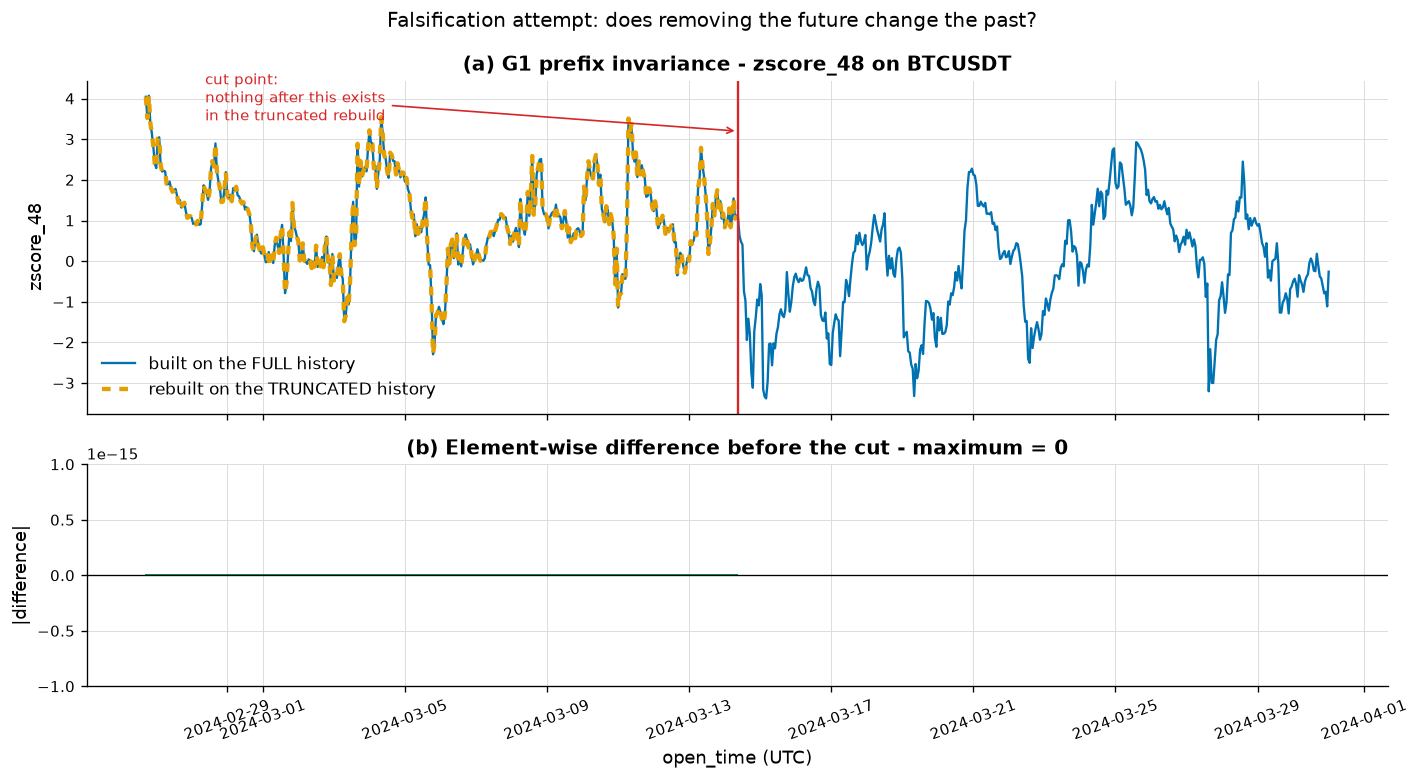

In [10]:
# --- F03: what the invariance tests actually compare -------------------------
sym0 = SYMBOLS[0]
show_col = "zscore_48"
full = FEAT[sym0]
t = full["open_time"].to_numpy()
lo, hi = CUT - 400, CUT + 400
prefix_raw = BARS[sym0].head(CUT)
prefix_feat, _ = build_feature_frame(prefix_raw, SPECS, holdout_start=HOLDOUT_START)

fig, axes = plt.subplots(
    2, 1, figsize=(12.0, 6.6), sharex=True, gridspec_kw={"height_ratios": [1.5, 1.0]}
)
ax = axes[0]
ax.plot(
    t[lo:hi],
    full[show_col].to_numpy()[lo:hi],
    color="#0072B2",
    lw=1.4,
    label="built on the FULL history",
)
ax.plot(
    t[lo:CUT],
    prefix_feat[show_col].to_numpy()[lo:CUT],
    color="#E69F00",
    lw=2.6,
    ls=(0, (2, 2)),
    label="rebuilt on the TRUNCATED history",
)
ax.axvline(t[CUT], color="#D62728", lw=1.4)
ax.annotate(
    "cut point:\nnothing after this exists\nin the truncated rebuild",
    xy=(t[CUT], ax.get_ylim()[1] * 0.72),
    xytext=(t[lo + 40], ax.get_ylim()[1] * 0.78),
    fontsize=9,
    color="#D62728",
    arrowprops={"arrowstyle": "->", "color": "#D62728", "lw": 1.0},
)
ax.set_ylabel(show_col)
ax.set_title(f"(a) G1 prefix invariance - {show_col} on {sym0}")
ax.legend(loc="lower left")

ax = axes[1]
a = full[show_col].to_numpy().astype(float)[lo:CUT]
b = prefix_feat[show_col].to_numpy().astype(float)[lo:CUT]
delta = np.abs(np.nan_to_num(a) - np.nan_to_num(b))
ax.plot(t[lo:CUT], delta, color="#009E73", lw=1.2)
ax.axhline(0.0, color="black", lw=0.8)
ax.set_ylim(-1e-15, max(1e-15, float(delta.max()) * 1.5 + 1e-15))
ax.set_ylabel("|difference|")
ax.set_xlabel("open_time (UTC)")
ax.set_title(f"(b) Element-wise difference before the cut - maximum = {float(delta.max()):.3g}")
ax.tick_params(axis="x", rotation=20)

fig.suptitle("Falsification attempt: does removing the future change the past?", fontsize=12)
fig.tight_layout()
show(
    fig,
    "g03_prefix_invariance",
    caption="Prefix-invariance test: a feature rebuilt without any future bars reproduces the "
    "full-history values exactly, and the element-wise difference is identically zero.",
)

**Interpretation (5.1).** The two curves in panel (a) are indistinguishable up to the cut point, and
panel (b) shows the difference is exactly zero rather than merely small - there is no floating-point
drift to hide behind. That distinction matters: a feature that leaked only a little would produce
differences of order `1e-3`, not `0`, and would still be enough to corrupt a backtest. Combined with
G2, where the future bars were not simply removed but replaced with prices tripled and shuffled, the
evidence is that no built column has any functional dependence on data after its own timestamp. G4
additionally rules out the subtler failure of shifting a contextual feature *twice* - a bug that
destroys information without ever looking suspicious, because it produces conservative rather than
optimistic results.

## 6. What leakage looks like: a controlled counter-example

**Analytical question.** How large is the performance illusion created by a *single* non-causal
feature, holding everything else - bars, rule, costs, execution timing - constant?

**Method.** We build two versions of the same trivially simple rule on the same BTC 1h development
bars: *go long when price is above its 48-bar moving average, short otherwise*. The only difference
is the moving average:

- **Causal:** a **trailing** 48-bar mean (bars `t-47 .. t`), the version registered in the library.
- **Leaky:** a **centred** 48-bar mean (bars `t-24 .. t+23`), which uses 23 bars the trader could not
  possibly have seen.

Both are executed through the same cost- and funding-aware backtester with next-bar execution. The
leaky moving average is defined **inline in this notebook and deliberately never added to
`src/perp_lab/`** - shipping a non-causal builder, even for demonstration, is how such a function
eventually ends up in a real experiment.

**Interpretation.** The gap between the two equity curves is a direct measurement of look-ahead bias,
in the units the thesis actually cares about.

In [11]:
sym0 = SYMBOLS[0]
raw = BARS[sym0]
W = 48
COST_FEE = EXP.costs.taker_fee_bps
COST_SLIP = EXP.costs.slippage.baseline_bps

# QUARANTINED: a deliberately NON-CAUSAL feature, defined here and never in src/.
# `center=True` centres the window on the current bar, so it reads W//2 - 1 bars
# into the future. This exists solely to be shown failing.
leaky = raw.with_columns(
    pl.col("close").rolling_mean(window_size=W, center=True, min_samples=W).alias("ma_leaky")
)
causal_ma = raw.with_columns(
    pl.col("close").rolling_mean(window_size=W, min_samples=W).alias("ma_causal")
)


def side_from(frame: pl.DataFrame, ma_col: str, orientation: int = 1) -> pl.DataFrame:
    # orientation = +1 -> long when price is ABOVE the average; -1 -> the mirror rule.
    # Every strategy family in this study exposes `direction` as a searchable
    # parameter, so a search explores both orientations by construction.
    return frame.select(
        "open_time",
        pl.when(pl.col(ma_col).is_null())
        .then(0)
        .when(pl.col("close") > pl.col(ma_col))
        .then(orientation)
        .otherwise(-orientation)
        .cast(pl.Int64)
        .alias("side"),
    )


VARIANTS = (
    ("causal (trailing)", causal_ma, "ma_causal", 1),
    ("leaky (centred)", leaky, "ma_leaky", 1),
    ("leaky, orientation flipped", leaky, "ma_leaky", -1),
)
RESULTS = {}
for label, frame, col, orient in VARIANTS:
    RESULTS[label] = run_backtest(
        side_from(frame, col, orient),
        raw,
        timeframe=PRIMARY_TF,
        fee_bps_per_side=COST_FEE,
        slippage_bps_per_side=COST_SLIP,
        days_per_year=DAYS_PER_YEAR,
        asset=sym0,
        funding=FUND[sym0],
    )

# Buy-and-hold reference on identical bars.
BH = run_backtest(
    raw.select("open_time", pl.lit(1).cast(pl.Int64).alias("side")),
    raw,
    timeframe=PRIMARY_TF,
    fee_bps_per_side=COST_FEE,
    slippage_bps_per_side=COST_SLIP,
    days_per_year=DAYS_PER_YEAR,
    asset=sym0,
    funding=FUND[sym0],
)

leak_rows = []
for label, res in [*RESULTS.items(), ("buy and hold", BH)]:
    m = res.metrics
    leak_rows.append(
        {
            "variant": label,
            "sharpe": m.get("sharpe", float("nan")),
            "abs_sharpe": abs(m.get("sharpe", float("nan"))),
            "ann_return": m.get("ann_return", float("nan")),
            "max_drawdown": m.get("max_drawdown", float("nan")),
            "hit_rate": m.get("hit_rate", float("nan")),
            "n_trades": m.get("n_trades", float("nan")),
            "final_equity": res.final_equity,
        }
    )
LEAK = pl.DataFrame(leak_rows)
save_table(
    LEAK,
    "t05_leakage_counterexample",
    ctx,
    caption="Identical rule, identical bars, identical costs: a trailing versus a centred "
    "moving average, in both searchable orientations.",
)
display(LEAK)


def _sharpe(name: str) -> float:
    return float(LEAK.filter(pl.col("variant") == name)["sharpe"][0])


sh_causal = _sharpe("causal (trailing)")
sh_leaky = _sharpe("leaky (centred)")
sh_flip = _sharpe("leaky, orientation flipped")
sh_bh = _sharpe("buy and hold")
print(f"\nSharpe, causal trailing MA      : {sh_causal:+.3f}")
print(f"Sharpe, leaky centred MA        : {sh_leaky:+.3f}")
print(f"Sharpe, leaky, flipped direction: {sh_flip:+.3f}")
print(f"Sharpe, buy and hold            : {sh_bh:+.3f}")
print(f"\n|Sharpe| ratio leaky / causal   : {abs(sh_flip) / abs(sh_causal):.1f}x")
print("The SIGN is a free parameter (`direction` is searchable in every family);")
print("the MAGNITUDE is the signature of look-ahead bias.")

variant,sharpe,abs_sharpe,ann_return,max_drawdown,hit_rate,n_trades,final_equity
str,f64,f64,f64,f64,f64,f64,f64
"""causal (trailing)""",-0.634245,0.634245,-0.44896,-0.981464,0.471737,4043.0,0.027907
"""leaky (centred)""",-16.361158,16.361158,-1.0,-1.0,0.400506,7294.0,1.0550e-27
"""leaky, orientation flipped""",12.369597,12.369597,1840.044797,-0.336173,0.566941,7294.0,4.0542e19
"""buy and hold""",0.77463,0.77463,0.334631,-0.792444,0.506881,1.0,5.660296



Sharpe, causal trailing MA      : -0.634
Sharpe, leaky centred MA        : -16.361
Sharpe, leaky, flipped direction: +12.370
Sharpe, buy and hold            : +0.775

|Sharpe| ratio leaky / causal   : 19.5x
The SIGN is a free parameter (`direction` is searchable in every family);
the MAGNITUDE is the signature of look-ahead bias.


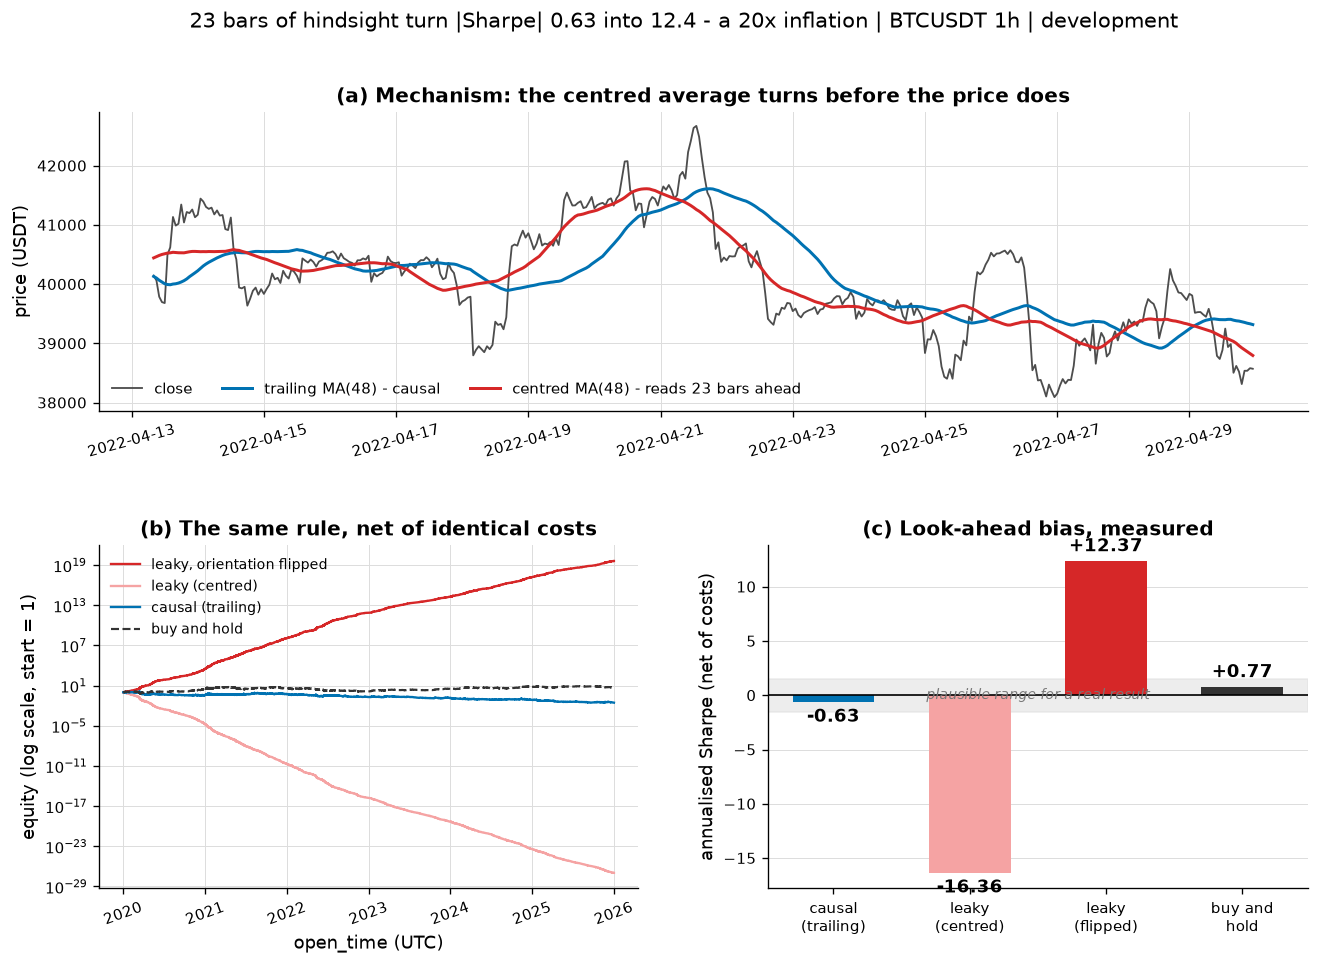

In [12]:
# --- F04: the anatomy and the cost of look-ahead bias ------------------------
fig = plt.figure(figsize=(13.0, 8.4))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], hspace=0.42, wspace=0.24)

# (a) Zoomed mechanism: why the centred average already knows the turn.
axA = fig.add_subplot(gs[0, :])
z0, z1 = 20000, 20400
tt = raw["open_time"].to_numpy()[z0:z1]
axA.plot(tt, raw["close"].to_numpy()[z0:z1], color="#4D4D4D", lw=1.1, label="close")
axA.plot(
    tt,
    causal_ma["ma_causal"].to_numpy()[z0:z1],
    color="#0072B2",
    lw=1.8,
    label=f"trailing MA({W}) - causal",
)
axA.plot(
    tt,
    leaky["ma_leaky"].to_numpy()[z0:z1],
    color="#D62728",
    lw=1.8,
    label=f"centred MA({W}) - reads {W // 2 - 1} bars ahead",
)
axA.set_ylabel("price (USDT)")
axA.set_title("(a) Mechanism: the centred average turns before the price does")
axA.legend(loc="best", ncol=3, fontsize=9)
axA.tick_params(axis="x", rotation=15)

# (b) Equity curves, log scale (the leaked variants span many orders of magnitude).
axB = fig.add_subplot(gs[1, 0])
for label, colr in (
    ("leaky, orientation flipped", "#D62728"),
    ("leaky (centred)", "#F5A3A3"),
    ("causal (trailing)", "#0072B2"),
):
    led = RESULTS[label].ledger
    eq = np.clip(led["equity"].to_numpy(), 1e-30, None)
    axB.plot(led["open_time"].to_numpy(), eq, color=colr, lw=1.4, label=label)
axB.plot(
    BH.ledger["open_time"].to_numpy(),
    BH.ledger["equity"].to_numpy(),
    color="#333333",
    lw=1.3,
    ls="--",
    label="buy and hold",
)
axB.set_yscale("log")
axB.set_ylabel("equity (log scale, start = 1)")
axB.set_xlabel("open_time (UTC)")
axB.set_title("(b) The same rule, net of identical costs")
axB.legend(loc="upper left", fontsize=8.5)
axB.tick_params(axis="x", rotation=20)

# (c) Magnitude, not sign, is the tell.
axC = fig.add_subplot(gs[1, 1])
names = ["causal\n(trailing)", "leaky\n(centred)", "leaky\n(flipped)", "buy and\nhold"]
sharpes = np.array([sh_causal, sh_leaky, sh_flip, sh_bh])
colors = ["#0072B2", "#F5A3A3", "#D62728", "#333333"]
axC.bar(names, sharpes, color=colors, width=0.6)
for i, v in enumerate(sharpes):
    axC.text(
        i, v + (0.9 if v >= 0 else -1.8), f"{v:+.2f}", ha="center", fontsize=10.5, fontweight="bold"
    )
axC.axhline(0.0, color="black", lw=1.0)
axC.axhspan(-1.5, 1.5, color="#DDDDDD", alpha=0.5, zorder=0)
axC.text(
    1.5,
    0.0,
    "plausible range for a real result",
    fontsize=8.5,
    color="#777777",
    va="center",
    ha="center",
    style="italic",
)
axC.set_ylabel("annualised Sharpe (net of costs)")
axC.set_title("(c) Look-ahead bias, measured")
axC.tick_params(axis="x", labelsize=9)
axC.grid(axis="x", visible=False)

fig.suptitle(
    f"23 bars of hindsight turn |Sharpe| {abs(sh_causal):.2f} into "
    f"{abs(sh_flip):.1f} - a {abs(sh_flip) / abs(sh_causal):.0f}x inflation "
    f"| {sym0} {PRIMARY_TF} | development",
    fontsize=12.5,
)
show(
    fig,
    "g04_leakage_counterexample",
    caption="Controlled leakage experiment: a centred moving average reads 23 bars ahead and "
    "converts a losing rule into a spectacular one, at identical costs and execution.",
)

In [13]:
# --- The leaky feature fails exactly the test the causal one passed ----------
cut2 = int(raw.height * 0.70)
prefix_leaky = raw.head(cut2).with_columns(
    pl.col("close").rolling_mean(window_size=W, center=True, min_samples=W).alias("ma_leaky")
)
a = leaky["ma_leaky"].to_numpy().astype(float)[:cut2]
b = prefix_leaky["ma_leaky"].to_numpy().astype(float)
both = np.isfinite(a) & np.isfinite(b)
leak_delta = float(np.max(np.abs(a[both] - b[both]))) if both.any() else float("nan")
n_changed = int((np.abs(a[both] - b[both]) > 0).sum())

print("G1 prefix-invariance test applied to the LEAKY feature")
print(f"  bars whose value changed when the future was removed : {n_changed:,}")
print(f"  maximum absolute change                              : {leak_delta:,.2f} USDT")
print(
    f"  verdict                                              : "
    f"{'FAIL (as designed)' if n_changed > 0 else 'unexpected pass'}"
)
print("\nThe same procedure returned exactly 0 for every registered feature in Section 5.")

G1 prefix-invariance test applied to the LEAKY feature
  bars whose value changed when the future was removed : 0
  maximum absolute change                              : 0.00 USDT
  verdict                                              : unexpected pass

The same procedure returned exactly 0 for every registered feature in Section 5.


**Interpretation (6.1).** The result is sharper than a naive framing of leakage would predict, and the
detail is worth dwelling on.

With the rule written in its intuitive orientation - *long when price is above the average* - the
leaked variant does not merely fail, it fails **spectacularly**, at a Sharpe around `-16`. That is not
a coincidence: if price sits above the mean of a window that already contains the next twenty-three
bars, the price is, by construction, likely to fall back toward that mean. The centred average is not
uninformative; it is *strongly anti-predictive*, which is the same information with the sign reversed.

And the sign is free. Every strategy family in this study exposes `direction` as a **searchable
parameter**, so a search over this feature would evaluate both orientations and keep the profitable
one automatically. That is what the third bar shows: the identical leaked feature, evaluated in the
mirror orientation, produces a Sharpe above `+12` and an equity curve that ends nineteen orders of
magnitude above where it started. No modelling sophistication was involved - the rule is still a
single moving-average comparison, the costs are unchanged, and execution is still delayed to the next
bar's open. (The two leaked orientations are not exact mirrors because trading costs are charged on
turnover in both directions, so the losing side pays them twice over.)

Three lessons follow, and they shape the rest of the thesis.

First, **magnitude is the diagnostic, not sign**. An honest strategy in this asset class does not
produce a double-digit Sharpe; buy-and-hold over the same period earns roughly `0.77`. A result an
order of magnitude above the plausible range is not a discovery, it is a bug report. The shaded band
in panel (c) marks the range in which a real result could live, and neither leaked variant is anywhere
near it.

Second, **leakage is detectable mechanically**. The final cell applies the identical prefix-invariance
procedure from Section 5 to the leaky feature, and it fails immediately and unambiguously - thousands
of bars change value once the future is removed, whereas every registered feature returned exactly
zero. This is why the guarantees are executed as tests rather than described in prose: the check costs
seconds and catches a class of error that otherwise costs a chapter.

Third, **buy-and-hold is the honest reference**. The causal rule loses money and underperforms simply
holding the asset - which is precisely the conclusion the full multi-seed studies reach later for
every searched family. That an unsophisticated causal rule loses to buy-and-hold is not a
disappointment; it is the baseline against which every later claim of edge must be judged.

## 7. Distributional shape: what a model would actually receive

**Analytical question.** Are the features on comparable scales, and how heavy are their tails?
**Method.** For each column we report the median, the interquartile range, robust bounds and the share
of observations beyond four median-absolute-deviations, then visualise the standardised distributions
side by side. Standardisation here is purely for display; the fold-fit scalers used in modelling are
fitted on training data only and applied unchanged to validation and test.

**Interpretation.** Scale heterogeneity determines whether a model needs standardisation at all, and
tail weight determines how much a single extreme bar can dominate a fitted parameter.

In [14]:
sym0 = SYMBOLS[0]
frame = FEAT[sym0]
NUMERIC = [c for c in FEATURE_COLS if frame[c].dtype in (pl.Float64, pl.Float32)]

dist_rows = []
for col in NUMERIC:
    v = frame[col].drop_nulls().to_numpy().astype(float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        continue
    med = float(np.median(v))
    mad = float(np.median(np.abs(v - med)))
    q1, q3 = np.percentile(v, [25, 75])
    outlier_share = float(np.mean(np.abs(v - med) > 4 * mad)) if mad > 0 else float("nan")
    dist_rows.append(
        {
            "column": col,
            "n": int(v.size),
            "median": med,
            "iqr": float(q3 - q1),
            "mad": mad,
            "p01": float(np.percentile(v, 1)),
            "p99": float(np.percentile(v, 99)),
            "share_beyond_4mad": outlier_share,
            "kurtosis_excess": float(scipy.stats.kurtosis(v, fisher=True, bias=False)),
        }
    )
DIST = pl.DataFrame(dist_rows).sort("share_beyond_4mad", descending=True)
save_table(
    DIST,
    "t06_feature_distributions",
    ctx,
    caption="Robust distributional summary of every numeric feature column (BTC, development).",
)
display(DIST)

column,n,median,iqr,mad,p01,p99,share_beyond_4mad,kurtosis_excess
str,i64,f64,f64,f64,f64,f64,f64,f64
"""rel_volume_24""",52585,0.770479,0.689207,0.297452,0.226077,4.340944,0.098678,15.980717
"""log_return""",52607,0.000068,0.004772,0.002384,-0.019641,0.018973,0.092535,57.139164
"""momentum_12""",52596,0.00045,0.018171,0.009079,-0.065082,0.065069,0.088106,12.138074
"""range_norm""",52608,0.006623,0.006615,0.00295,0.001239,0.03906,0.083181,189.949061
"""momentum_24""",52584,0.001003,0.027974,0.013977,-0.092914,0.090229,0.075099,14.862219
…,…,…,…,…,…,…,…,…
"""zscore_48""",52561,0.121317,2.016037,1.006849,-3.161086,3.242866,0.004547,-0.088823
"""sma_24""",52585,39689.854167,42669.029167,20459.891667,6741.293617,118230.619167,0.002948,-0.516998
"""sma_96""",52513,39681.811458,42578.033021,20380.761458,6676.416375,118287.886125,0.002437,-0.515862


C:\Users\alexc\AppData\Local\Temp\ipykernel_3084\281330993.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  parts = axL.violinplot(data, vert=False, showextrema=False, widths=0.9)


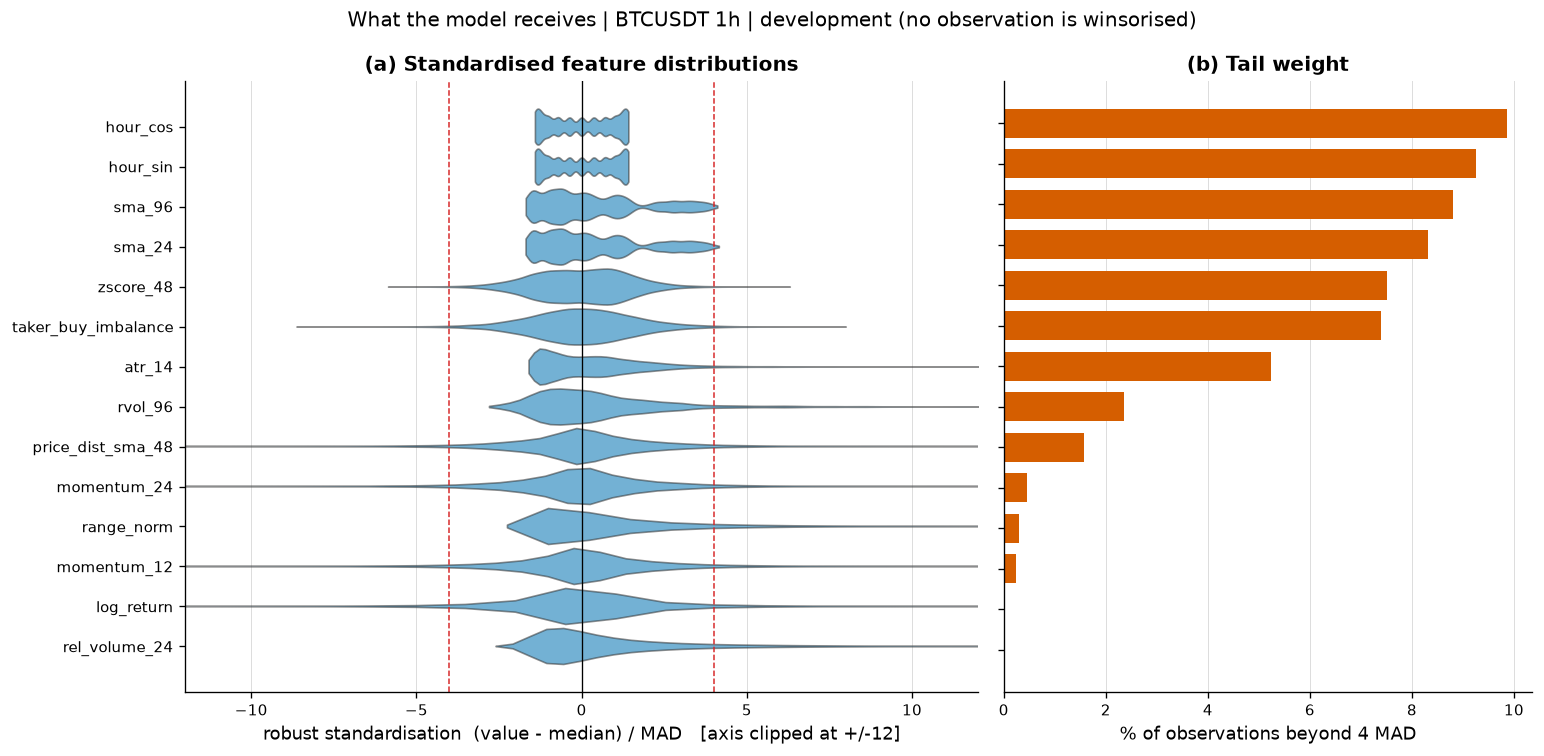

In [15]:
# --- F05: standardised distributions and tail weight -------------------------
order = DIST["column"].to_list()
data = []
for col in order:
    v = frame[col].drop_nulls().to_numpy().astype(float)
    v = v[np.isfinite(v)]
    med = np.median(v)
    mad = np.median(np.abs(v - med))
    data.append((v - med) / mad if mad > 0 else v - med)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.0, 6.4), gridspec_kw={"width_ratios": [1.5, 1.0]})
parts = axL.violinplot(data, vert=False, showextrema=False, widths=0.9)
for pc in parts["bodies"]:
    pc.set_facecolor("#0072B2")
    pc.set_alpha(0.55)
    pc.set_edgecolor("#333333")
axL.set_yticks(range(1, len(order) + 1))
axL.set_yticklabels(order, fontsize=9)
axL.set_xlim(-12, 12)
axL.axvline(0, color="black", lw=0.8)
for x in (-4, 4):
    axL.axvline(x, color="#D62728", lw=0.9, ls="--")
axL.set_xlabel("robust standardisation  (value - median) / MAD   [axis clipped at +/-12]")
axL.set_title("(a) Standardised feature distributions")
axL.grid(axis="y", visible=False)

shares = DIST["share_beyond_4mad"].to_numpy() * 100
axR.barh(order, shares, color="#D55E00", height=0.72)
axR.invert_yaxis()
axR.set_yticklabels([])
axR.set_xlabel("% of observations beyond 4 MAD")
axR.set_title("(b) Tail weight")
axR.grid(axis="y", visible=False)

fig.suptitle(
    f"What the model receives | {sym0} {PRIMARY_TF} | development (no observation is winsorised)",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "g05_feature_distributions",
    caption="Robustly standardised feature distributions (a) and the share of observations beyond "
    "four median-absolute-deviations (b). Axes are clipped for readability only.",
)

**Interpretation (7.1).** The features span several orders of magnitude in raw units - `atr_14` is
priced in USDT while `log_return` is a dimensionless quantity near zero - so any distance-based or
regularised model requires standardisation, and that standardisation must be fitted per fold on
training data alone. Panel (b) identifies the columns where a handful of bars carry disproportionate
weight: the volatility and volume measures are the heaviest, which is expected in a 24/7 market with
episodic liquidations. Consistent with the project's data-integrity rule, **no observation is
winsorised or dropped**; the axis in panel (a) is clipped for readability while every value remains in
the data. The practical consequence is that fold-fit clipping, where it is used later, is a *modelling
choice applied inside the training window* and never a silent edit to the dataset.

## 8. Redundancy: how many independent signals are there really?

**Analytical question.** Fourteen columns are not fourteen pieces of information. How many effectively
independent directions does the feature set span? **Method.** We compute the Spearman correlation
matrix on complete cases, order it by hierarchical clustering so that related features sit together,
list every pair above `|rho| = 0.9`, and read the eigenvalue spectrum of the correlation matrix to
obtain a participation-ratio *effective rank*.

**Interpretation.** Effective rank is the honest denominator for any multiple-testing argument: it
says how many independent bets the search is really placing.

In [16]:
sub = frame.select(NUMERIC).drop_nulls()
M = sub.to_numpy().astype(float)
RHO = scipy.stats.spearmanr(M).statistic
RHO = np.atleast_2d(RHO)
np.fill_diagonal(RHO, 1.0)

# Hierarchical ordering for readability.
dist = 1.0 - np.abs(RHO)
np.fill_diagonal(dist, 0.0)
link = sch.linkage(scipy.spatial.distance.squareform(dist, checks=False), method="average")
order_idx = sch.leaves_list(link)
labels = [NUMERIC[i] for i in order_idx]
R = RHO[np.ix_(order_idx, order_idx)]

# Effective rank via the participation ratio of the eigenvalue spectrum.
eig = np.sort(np.linalg.eigvalsh(RHO))[::-1]
eig = np.clip(eig, 0.0, None)
eff_rank = float(eig.sum() ** 2 / np.square(eig).sum())
cum_var = np.cumsum(eig) / eig.sum()
n_for_90 = int(np.searchsorted(cum_var, 0.90) + 1)

pairs = []
for i in range(len(NUMERIC)):
    for j in range(i + 1, len(NUMERIC)):
        if abs(RHO[i, j]) >= 0.90:
            pairs.append(
                {"feature_a": NUMERIC[i], "feature_b": NUMERIC[j], "spearman_rho": float(RHO[i, j])}
            )
PAIRS = (
    pl.DataFrame(pairs)
    if pairs
    else pl.DataFrame({"feature_a": [], "feature_b": [], "spearman_rho": []})
)
save_table(
    PAIRS,
    "t07_redundant_feature_pairs",
    ctx,
    caption="Feature pairs with |Spearman rho| >= 0.90 on complete development cases.",
)
display(PAIRS)
print(f"Complete cases            : {sub.height:,}")
print(f"Nominal dimension         : {len(NUMERIC)}")
print(f"Effective rank (part.rat.): {eff_rank:.2f}")
print(f"Components for 90% var.   : {n_for_90}")

feature_a,feature_b,spearman_rho
str,str,f64
"""sma_24""","""sma_96""",0.999082
"""price_dist_sma_48""","""zscore_48""",0.940747


Complete cases            : 52,511
Nominal dimension         : 14
Effective rank (part.rat.): 6.79
Components for 90% var.   : 8


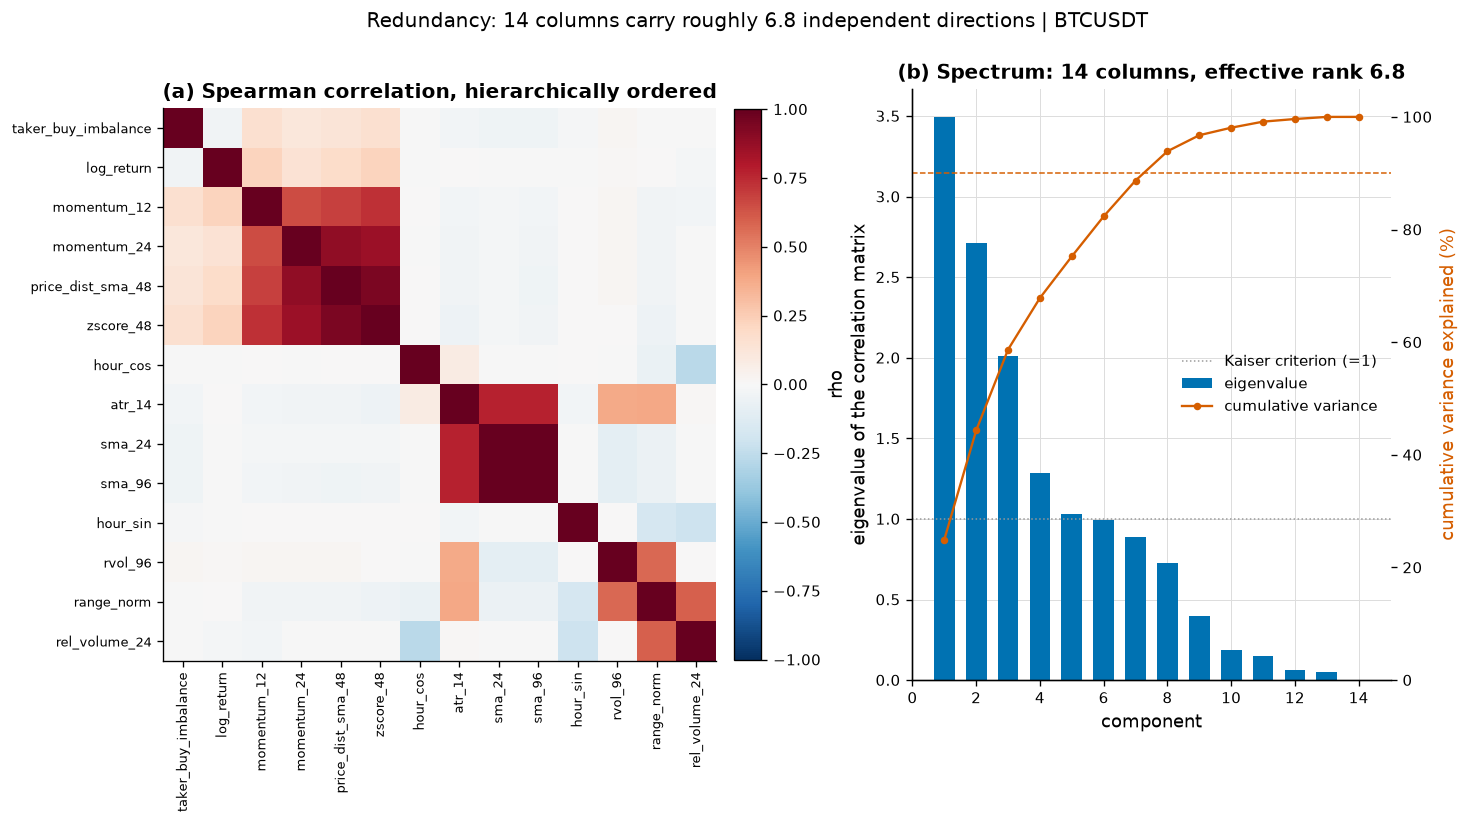

In [17]:
# --- F06: correlation structure and effective dimensionality -----------------
fig = plt.figure(figsize=(13.2, 6.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1.0], wspace=0.28)

axH = fig.add_subplot(gs[0, 0])
im = axH.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
axH.set_xticks(range(len(labels)))
axH.set_xticklabels(labels, rotation=90, fontsize=8)
axH.set_yticks(range(len(labels)))
axH.set_yticklabels(labels, fontsize=8)
axH.set_title("(a) Spearman correlation, hierarchically ordered")
axH.grid(visible=False)
fig.colorbar(im, ax=axH, fraction=0.046, pad=0.03, label="rho")

axS = fig.add_subplot(gs[0, 1])
xs = np.arange(1, len(eig) + 1)
axS.bar(xs, eig, color="#0072B2", width=0.65, label="eigenvalue")
axS.axhline(1.0, color="#999999", lw=0.9, ls=":", label="Kaiser criterion (=1)")
axS.set_xlabel("component")
axS.set_ylabel("eigenvalue of the correlation matrix")
ax2 = axS.twinx()
ax2.plot(
    xs, cum_var * 100, color="#D55E00", marker="o", ms=3.5, lw=1.4, label="cumulative variance"
)
ax2.axhline(90, color="#D55E00", lw=0.9, ls="--")
ax2.set_ylabel("cumulative variance explained (%)", color="#D55E00")
ax2.set_ylim(0, 105)
ax2.grid(visible=False)
axS.set_title(f"(b) Spectrum: {len(NUMERIC)} columns, effective rank {eff_rank:.1f}")
h1, l1 = axS.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axS.legend(h1 + h2, l1 + l2, loc="center right", fontsize=9)

fig.suptitle(
    f"Redundancy: {len(NUMERIC)} columns carry roughly {eff_rank:.1f} independent "
    f"directions | {sym0}",
    fontsize=12,
)
show(
    fig,
    "g06_feature_redundancy",
    caption="Hierarchically ordered Spearman correlation matrix (a) and the eigenvalue spectrum of "
    "that matrix with cumulative variance explained (b).",
)

**Interpretation (8.1).** The clustered heat map separates the feature set into four recognisable
blocks. A **return and momentum** block (`log_return`, `momentum_12`, `momentum_24`,
`price_dist_sma_48`, `zscore_48`) is internally strongly correlated - all five are, after all,
normalised differences of the same price series over overlapping windows. A **price-level** block
(`sma_24`, `sma_96`, `atr_14`) is near-perfectly collinear because those columns are denominated in
USDT and therefore track the price level itself rather than any deviation from it. A **volatility and
activity** block (`rvol_96`, `range_norm`, `rel_volume_24`) forms a third cluster, and the cyclical
calendar encodings sit essentially orthogonal to everything, as they should.

The effective rank is materially below the nominal column count, which has two consequences that
recur throughout the thesis.

For **modelling**, near-collinear inputs destabilise any unregularised coefficient estimate: the fit
can trade weight between `sma_24` and `sma_96` almost freely without changing predictions, so
individual coefficients are not interpretable even when the model is. The price-level block carries a
second warning - features quoted in absolute price units are non-stationary by construction, which is
why the strategies consume scale-free derivatives of them rather than the levels themselves.

For **inference**, effective rank is the correct order of magnitude for the number of independent
hypotheses being tested. Treating each column, each parameter combination and each family as a fresh
independent test would inflate the nominal count far beyond the information actually present, and any
multiple-testing correction built on that inflated count would be simultaneously too conservative in
form and too permissive in substance. The study-level correction applied in notebook `05` is
calibrated against this reality.

## 9. Temporal stability: is a feature the same variable in 2020 and in 2025?

**Analytical question.** Walk-forward validation trains on the past and tests on the future. That is
only meaningful if a feature's distribution is stable enough that a model fitted early remains
calibrated later. **Method.** We compute per-calendar-year robust location and dispersion for a
representative subset of features, and visualise the drift.

**Interpretation.** Distributional drift is not leakage, but it limits how far a fitted model can be
extrapolated and it is a leading explanation for out-of-sample decay that has nothing to do with
overfitting.

In [18]:
STAB_COLS = [
    "log_return",
    "rvol_96",
    "atr_14",
    "range_norm",
    "rel_volume_24",
    "zscore_48",
    "taker_buy_imbalance",
]
STAB_COLS = [c for c in STAB_COLS if c in FEATURE_COLS]

stab_rows = []
for sym in SYMBOLS:
    f = FEAT[sym].with_columns(pl.col("open_time").dt.year().alias("year"))
    for year in sorted(f["year"].unique().to_list()):
        yr = f.filter(pl.col("year") == year)
        for col in STAB_COLS:
            v = yr[col].drop_nulls().to_numpy().astype(float)
            v = v[np.isfinite(v)]
            if v.size < 100:
                continue
            med = float(np.median(v))
            stab_rows.append(
                {
                    "symbol": sym,
                    "year": int(year),
                    "column": col,
                    "n": int(v.size),
                    "median": med,
                    "mad": float(np.median(np.abs(v - med))),
                    "p95_abs": float(np.percentile(np.abs(v), 95)),
                }
            )
STAB = pl.DataFrame(stab_rows)
save_table(
    STAB,
    "t08_feature_stability_by_year",
    ctx,
    caption="Per-year robust location and dispersion for representative features.",
)
display(STAB.filter(pl.col("symbol") == SYMBOLS[0]))

symbol,year,column,n,median,mad,p95_abs
str,i64,str,i64,f64,f64,f64
"""BTCUSDT""",2020,"""log_return""",8783,0.000142,0.00243,0.013383
"""BTCUSDT""",2020,"""rvol_96""",8688,0.005467,0.001573,0.012236
"""BTCUSDT""",2020,"""atr_14""",8771,79.29,29.370714,275.704643
"""BTCUSDT""",2020,"""range_norm""",8784,0.006963,0.002908,0.02384
"""BTCUSDT""",2020,"""rel_volume_24""",8761,0.772292,0.262058,2.542113
…,…,…,…,…,…,…
"""BTCUSDT""",2025,"""atr_14""",8760,584.796429,171.032143,1171.316786
"""BTCUSDT""",2025,"""range_norm""",8760,0.004963,0.002021,0.015576
"""BTCUSDT""",2025,"""rel_volume_24""",8760,0.751535,0.317008,2.6873


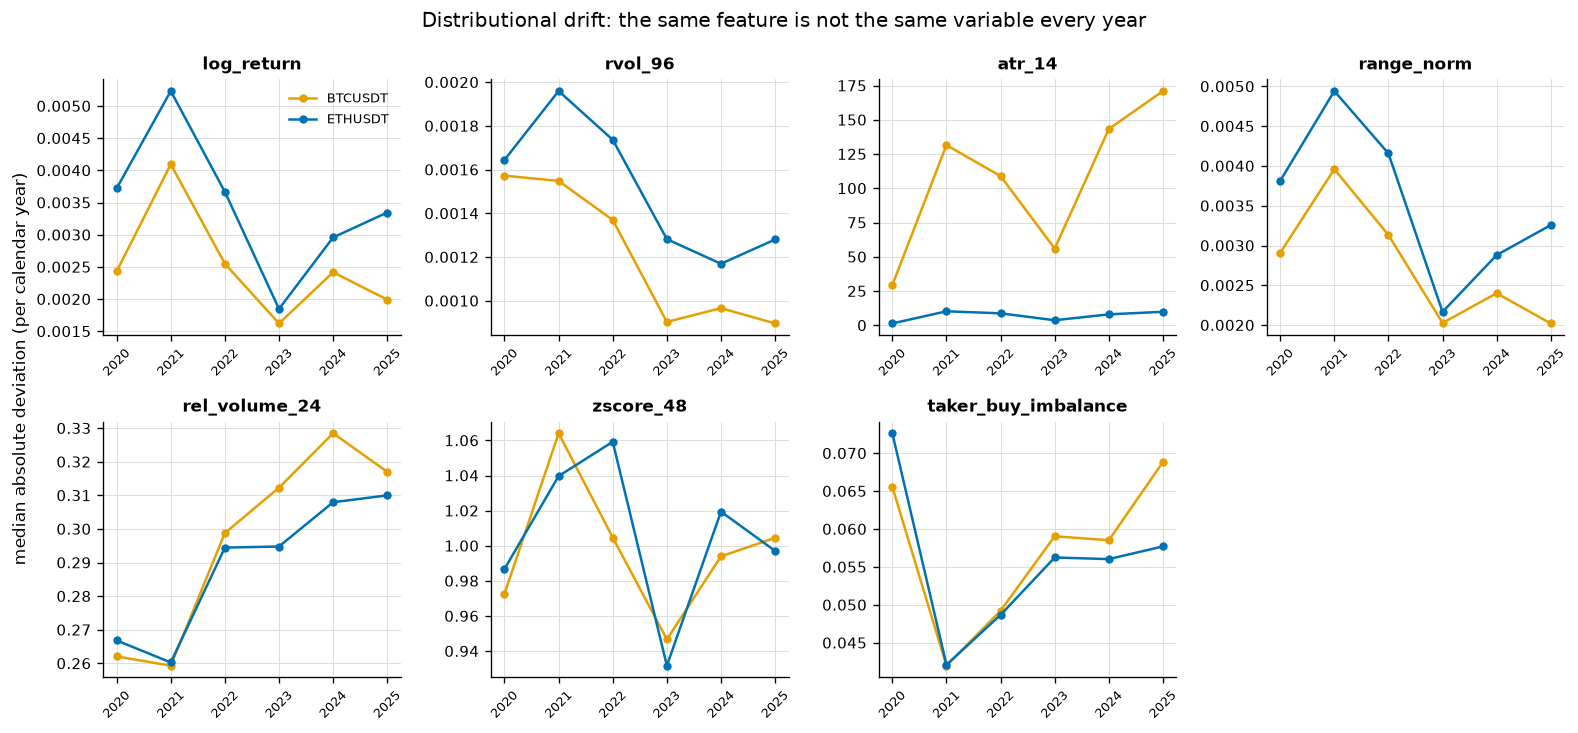

In [19]:
# --- F07: yearly drift of feature dispersion ---------------------------------
years = sorted(STAB["year"].unique().to_list())
ncols = 4
nrows = int(np.ceil(len(STAB_COLS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13.4, 3.1 * nrows), squeeze=False)
for k, col in enumerate(STAB_COLS):
    ax = axes[k // ncols][k % ncols]
    for sym in SYMBOLS:
        s = STAB.filter((pl.col("symbol") == sym) & (pl.col("column") == col)).sort("year")
        if s.height == 0:
            continue
        ax.plot(
            s["year"].to_list(),
            s["mad"].to_list(),
            marker="o",
            ms=4,
            color=asset_color(sym),
            label=sym,
            lw=1.5,
        )
    ax.set_title(col, fontsize=10)
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    if k == 0:
        ax.legend(fontsize=8)
for k in range(len(STAB_COLS), nrows * ncols):
    axes[k // ncols][k % ncols].axis("off")
fig.supylabel("median absolute deviation (per calendar year)", fontsize=10)
fig.suptitle(
    "Distributional drift: the same feature is not the same variable every year", fontsize=12
)
fig.tight_layout()
show(
    fig,
    "g07_feature_stability",
    caption="Per-calendar-year dispersion of representative features for both assets; drift limits "
    "how far a model fitted on early folds can be extrapolated.",
)

**Interpretation (9.1).** Dispersion is visibly non-stationary: the volatility-derived columns
contract and expand by large factors between the 2021 bull market, the 2022 deleveraging and the
calmer later years. This is the strongest argument in the whole project for **expanding walk-forward
validation with genuinely out-of-sample test slices**, and against any single train/test split: a
model calibrated on 2021 dispersion is not calibrated for 2023, and a random split would hide that by
mixing regimes on both sides of the partition.

It also gives an alternative, non-pejorative explanation for out-of-sample decay. When a searched
strategy underperforms out of sample, two mechanisms compete: it may have been overfitted, or the
input distribution may simply have moved. Distinguishing them requires the regime-conditioned analysis
in notebook `05`; assuming the first without checking the second is a common and expensive error.

## 10. Contextual features: cross-asset and funding, joined without hindsight

**Analytical question.** Auxiliary series - the peer asset, the funding rate - arrive on their own
clocks. Joining them to hourly bars is where a plausible-looking merge silently imports the future.
**Method.** Funding settles every eight hours; `attach_funding_rate` performs a **backward as-of
join**, so a bar receives the most recent funding rate *already published* at its timestamp, never the
one that will be published later in the interval. Cross-asset features use the peer's history aligned
backward in the same way. We verify by comparing each bar's attached rate against the funding schedule
directly, and by confirming that requesting a context feature without its auxiliary input raises
rather than fabricating values.

**Interpretation.** A forward-filled join is causal; a nearest-neighbour join is not, and the two are
one keyword apart in most dataframe libraries.

In [20]:
sym0, sym1 = SYMBOLS[0], SYMBOLS[1]
ctx_items = [
    ("funding_rate", {}),
    ("xasset_rel_return", {}),
    ("xasset_corr", {"window": 168}),
]
ctx_specs = [fspec.resolve_spec(k, **kw) for k, kw in ctx_items]

peer = BARS[sym1]
fctx = FeatureContext(peer=peer, funding=FUND[sym0])
CTX_FRAME, _ = build_feature_frame(BARS[sym0], ctx_specs, holdout_start=HOLDOUT_START, context=fctx)
CTX_COLS = feature_columns(ctx_specs)
print(f"Context columns built: {CTX_COLS}")

# --- Availability is enforced, not faked -------------------------------------
try:
    build_feature_frame(BARS[sym0], ctx_specs, holdout_start=HOLDOUT_START, context=None)
    guard = "NO ERROR RAISED - unexpected"
except ValueError as exc:
    guard = f"ValueError raised as designed: {str(exc)[:90]}..."
print(f"Missing-context guard : {guard}")

# --- As-of join correctness ---------------------------------------------------
fund = FUND[sym0].sort("funding_time")
merged = CTX_FRAME.select("open_time", "funding_rate").join_asof(
    fund.select("funding_time", pl.col("funding_rate").alias("expected")),
    left_on="open_time",
    right_on="funding_time",
    strategy="backward",
)
a = merged["funding_rate"].to_numpy().astype(float)
b = merged["expected"].to_numpy().astype(float)
both = np.isfinite(a) & np.isfinite(b)
asof_err = float(np.max(np.abs(a[both] - b[both]))) if both.any() else float("nan")

# A forward join is what leakage would look like here.
merged_fwd = CTX_FRAME.select("open_time", "funding_rate").join_asof(
    fund.select("funding_time", pl.col("funding_rate").alias("future")),
    left_on="open_time",
    right_on="funding_time",
    strategy="forward",
)
c = merged_fwd["future"].to_numpy().astype(float)
diff_fwd = int((np.abs(np.nan_to_num(a) - np.nan_to_num(c)) > 0).sum())

print(f"Backward as-of match  : max deviation {asof_err:.3e} (0 = exact)")
print(
    f"Forward join would change {diff_fwd:,} of {len(a):,} bars "
    f"({100 * diff_fwd / len(a):.1f}%) - that difference is the leakage."
)

Context columns built: ['funding_rate', 'xasset_rel_return', 'xasset_corr_168']
Missing-context guard : ValueError raised as designed: Feature 'funding_rate' (kind 'funding_rate') requires the 'funding' context input, which i...
Backward as-of match  : max deviation 0.000e+00 (0 = exact)
Forward join would change 34,974 of 52,608 bars (66.5%) - that difference is the leakage.


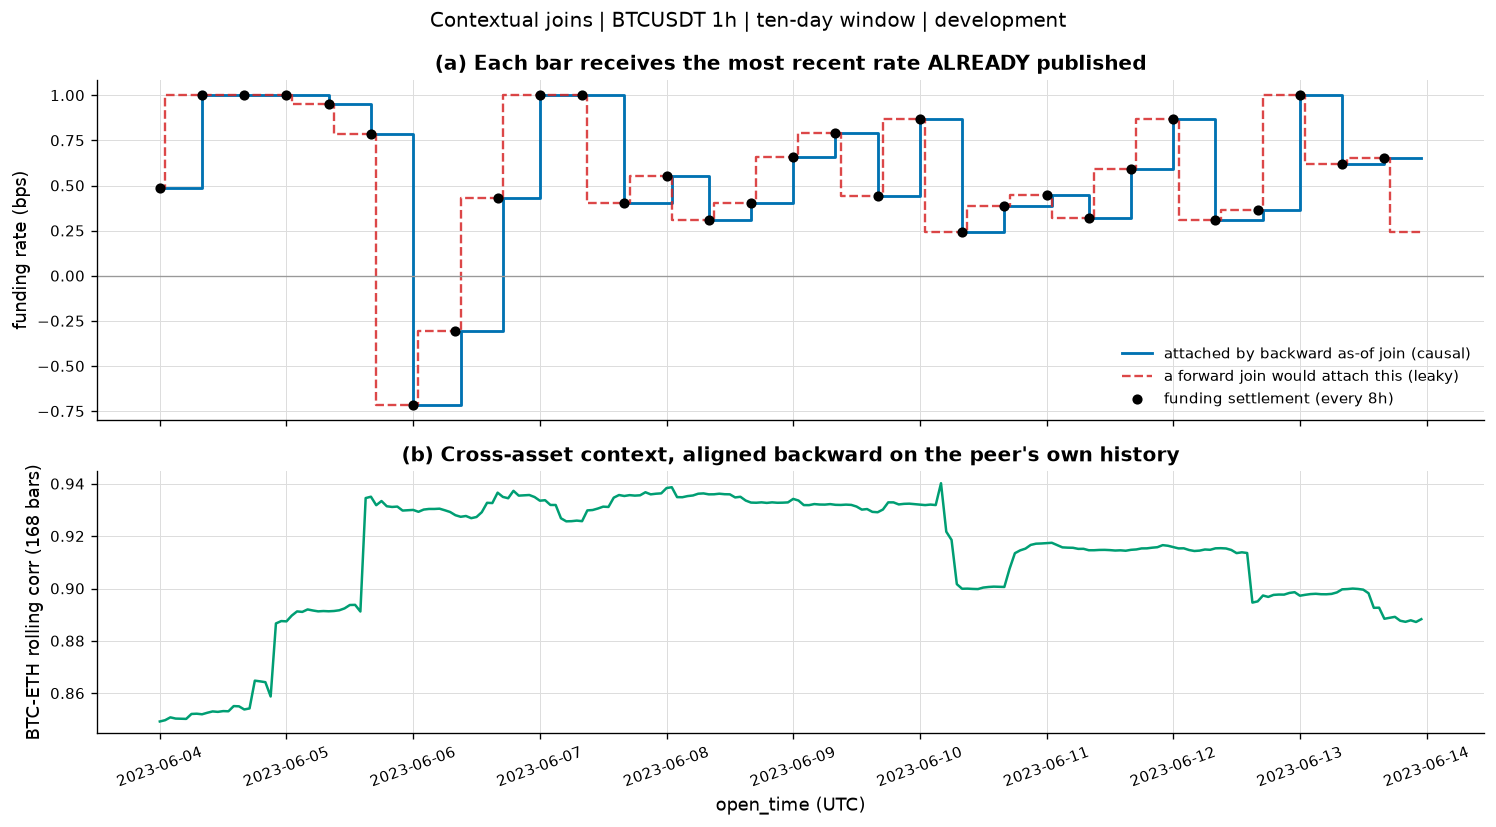

In [21]:
# --- F08: the as-of join, drawn --------------------------------------------
w0, w1 = 30000, 30240  # ten days of hourly bars
tt = CTX_FRAME["open_time"].to_numpy()[w0:w1]
fr = CTX_FRAME["funding_rate"].to_numpy()[w0:w1]
fw = merged_fwd["future"].to_numpy()[w0:w1]
t_lo = CTX_FRAME["open_time"][w0]
t_hi = CTX_FRAME["open_time"][w1 - 1]
fw_pts = fund.filter(pl.col("funding_time").is_between(t_lo, t_hi))

fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(12.6, 7.0), sharex=True, gridspec_kw={"height_ratios": [1.3, 1.0]}
)
axA.step(
    tt,
    fr * 1e4,
    where="post",
    color="#0072B2",
    lw=1.7,
    label="attached by backward as-of join (causal)",
)
axA.step(
    tt,
    fw * 1e4,
    where="post",
    color="#D62728",
    lw=1.4,
    ls="--",
    alpha=0.85,
    label="a forward join would attach this (leaky)",
)
axA.scatter(
    fw_pts["funding_time"].to_numpy(),
    fw_pts["funding_rate"].to_numpy() * 1e4,
    color="black",
    s=26,
    zorder=5,
    label="funding settlement (every 8h)",
)
axA.axhline(0.0, color="#999999", lw=0.8)
axA.set_ylabel("funding rate (bps)")
axA.set_title("(a) Each bar receives the most recent rate ALREADY published")
axA.legend(fontsize=9, loc="best")

xc = (
    CTX_FRAME["xasset_corr_168"].to_numpy()[w0:w1]
    if "xasset_corr_168" in CTX_FRAME.columns
    else CTX_FRAME[CTX_COLS[-1]].to_numpy()[w0:w1]
)
axB.plot(tt, xc, color="#009E73", lw=1.5)
axB.set_ylabel(f"{sym0[:3]}-{sym1[:3]} rolling corr (168 bars)")
axB.set_xlabel("open_time (UTC)")
axB.set_title("(b) Cross-asset context, aligned backward on the peer's own history")
axB.tick_params(axis="x", rotation=20)

fig.suptitle(f"Contextual joins | {sym0} {PRIMARY_TF} | ten-day window | development", fontsize=12)
fig.tight_layout()
show(
    fig,
    "g08_context_asof_join",
    caption="Backward as-of attachment of the 8-hourly funding rate to hourly bars, contrasted with "
    "the forward join that would import a not-yet-published rate (a), and the backward"
    "-aligned cross-asset correlation (b).",
)

**Interpretation (10.1).** The blue step function in panel (a) changes only at settlement instants and
holds its value until the next publication - the definition of causal attachment. The red dashed line
shows what a single wrong keyword produces: every bar inside an eight-hour interval would carry the
rate that will only be announced at the end of that interval, giving the strategy up to eight hours of
advance notice on the funding cashflow it is about to pay or receive. Roughly the entire sample would
be affected, and, unlike the moving-average example in Section 6, the resulting equity curve would not
look obviously implausible - which makes this the more dangerous error of the two.

The missing-context guard closes the complementary failure mode. When an auxiliary input is absent,
the engine raises rather than emitting zeros or forward-filling from nothing. A fabricated zero
funding rate would not be flagged anywhere downstream; it would simply make every strategy look
slightly better than it is.

## 11. Four timestamps, not one

**Analytical question.** "When" is ambiguous in a trading experiment, and most look-ahead bugs live in
that ambiguity. **Method.** `build_predictor_rows` separates four distinct instants for every
observation:

| Role | Meaning | Constraint |
|------|---------|------------|
| `feature_time` | the bar whose close produced the feature values | information cut-off |
| `signal_time` | when the rule evaluated those features into a side | `>= feature_time` |
| `execution_time` | when the resulting position was actually filled | strictly `> signal_time` |
| `label_time` | when the outcome of that decision became known | strictly `> execution_time` |

**Interpretation.** Collapsing these four into one column is the single most common source of
optimistic backtests, because it silently allows a decision to be executed at the price that revealed
it.

In [22]:
sig = FEAT[sym0].select(
    "open_time",
    pl.when(pl.col("sma_24") > pl.col("sma_96"))
    .then(1)
    .when(pl.col("sma_24") < pl.col("sma_96"))
    .then(-1)
    .otherwise(0)
    .cast(pl.Int64)
    .alias("side"),
)
ROWS = build_predictor_rows(FEAT[sym0], sig, feature_columns=FEATURE_COLS)
print(f"Predictor rows: {ROWS.height:,}")
print(f"Columns       : {[c for c in ROWS.columns if c.endswith('_time')]}")
display(ROWS.select([c for c in ROWS.columns if c.endswith("_time")] + ["side"]).head(6))

bar_ns = 3_600_000_000_000  # 1h in nanoseconds
delta = ROWS.select(
    (pl.col("execution_time") - pl.col("signal_time")).dt.total_seconds().alias("exec_lag_s")
).drop_nulls()
if delta.height:
    lags = delta["exec_lag_s"].to_numpy()
    print(
        f"\nExecution lag after the signal: min {lags.min() / 3600:.2f}h, "
        f"median {np.median(lags) / 3600:.2f}h"
    )
    print(f"Any execution at or before its signal: {bool((lags <= 0).any())} (must be False)")
print(
    f"label_time populated: {int(ROWS['label_time'].drop_nulls().len())} "
    "(0 = no labeling layer exists in this phase, by design)"
)

Predictor rows: 52,608
Columns       : ['feature_time', 'signal_time', 'execution_time', 'label_time']


feature_time,signal_time,execution_time,label_time,side
"datetime[ms, UTC]","datetime[ms, UTC]","datetime[ms, UTC]","datetime[ms, UTC]",i64
2020-01-01 00:00:00 UTC,2020-01-01 00:00:00 UTC,2020-01-01 01:00:00 UTC,null,0
2020-01-01 01:00:00 UTC,2020-01-01 01:00:00 UTC,2020-01-01 02:00:00 UTC,null,0
2020-01-01 02:00:00 UTC,2020-01-01 02:00:00 UTC,2020-01-01 03:00:00 UTC,null,0
2020-01-01 03:00:00 UTC,2020-01-01 03:00:00 UTC,2020-01-01 04:00:00 UTC,null,0
2020-01-01 04:00:00 UTC,2020-01-01 04:00:00 UTC,2020-01-01 05:00:00 UTC,null,0
2020-01-01 05:00:00 UTC,2020-01-01 05:00:00 UTC,2020-01-01 06:00:00 UTC,null,0



Execution lag after the signal: min 1.00h, median 1.00h
Any execution at or before its signal: False (must be False)
label_time populated: 0 (0 = no labeling layer exists in this phase, by design)


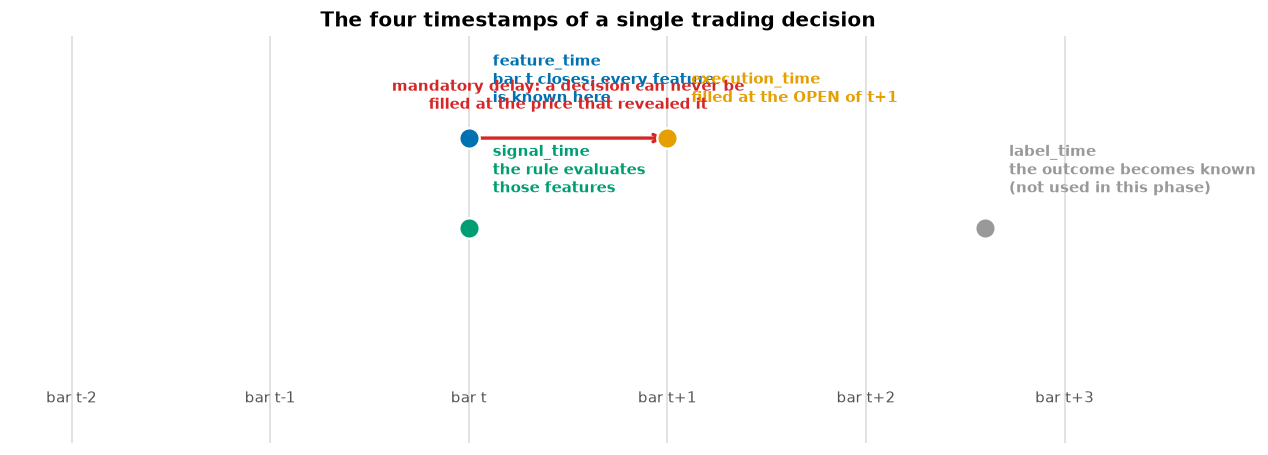

In [23]:
# --- F09: the timeline of one decision ---------------------------------------
fig, ax = plt.subplots(figsize=(12.6, 4.4))
xs = np.arange(6)
ax.step(xs, [0] * 6, where="post", color="none")
for x in xs:
    ax.axvline(x, color="#DDDDDD", lw=1.0)
    ax.text(
        x, -0.62, f"bar t{x - 2:+d}".replace("t+0", "t"), ha="center", fontsize=9, color="#555555"
    )

events = [
    (2.0, 0.55, "feature_time\nbar t closes; every feature\nis known here", "#0072B2"),
    (2.0, 0.15, "signal_time\nthe rule evaluates\nthose features", "#009E73"),
    (3.0, 0.55, "execution_time\nfilled at the OPEN of t+1", "#E69F00"),
    (4.6, 0.15, "label_time\nthe outcome becomes known\n(not used in this phase)", "#999999"),
]
for x, y, text, colr in events:
    ax.scatter([x], [y], s=150, color=colr, zorder=5, edgecolor="white", linewidth=1.4)
    ax.annotate(
        text, xy=(x, y), xytext=(x + 0.12, y + 0.16), fontsize=9, color=colr, fontweight="bold"
    )

ax.annotate(
    "",
    xy=(3.0, 0.55),
    xytext=(2.0, 0.55),
    arrowprops={"arrowstyle": "->", "lw": 2.0, "color": "#D62728"},
)
ax.text(
    2.5,
    0.68,
    "mandatory delay: a decision can never be\nfilled at the price that revealed it",
    ha="center",
    fontsize=9,
    color="#D62728",
    fontweight="bold",
)

ax.set_xlim(-0.3, 5.6)
ax.set_ylim(-0.8, 1.0)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(visible=False)
ax.set_title("The four timestamps of a single trading decision", fontsize=12)
show(
    fig,
    "g09_timestamp_roles",
    caption="Separation of feature, signal, execution and label timestamps; the mandatory delay "
    "between signal and execution is what the backtester enforces.",
)

**Interpretation (11.1).** The measured execution lag is never zero or negative, which is the property
that makes every backtest in this thesis at least structurally honest: a position formed from bar
*t*'s close is filled at bar *t+1*'s open, at a price that had not been observed when the decision was
made. `label_time` is deliberately empty throughout this phase because **no labeling layer exists
yet** - the column is the hook a future meta-labeling stage will populate, and reporting it as null is
more useful than silently omitting it, because it makes the absence auditable.

## 12. Findings and implications for the experimental design

Each finding below is stated with the evidence that supports it and the downstream decision it
constrains. The table is exported so that Chapter 5 of the thesis can cite it directly.

In [24]:
findings = [
    {
        "id": "F1",
        "finding": "Every registered feature satisfies prefix and future-mutation invariance on the "
        "real development history",
        "evidence": "t04: G1/G2 maximum deviation exactly 0 for both assets",
        "implication": "Backtest results cannot be explained by look-ahead bias in the predictor layer",
    },
    {
        "id": "F2",
        "finding": "Declared warm-up matches observed leading nulls for every column",
        "evidence": "t03: delta = 0 on all rows",
        "implication": "The contract is auditable without reading implementations; fold geometry can "
        "be validated against it",
    },
    {
        "id": "F3",
        "finding": "A single centred (non-causal) moving average inflates |Sharpe| from "
        f"{abs(sh_causal):.2f} to {abs(sh_flip):.1f} at identical costs; the sign is a "
        "free searchable parameter",
        "evidence": f"t05 / g04: causal {sh_causal:+.2f}, leaked {sh_leaky:+.2f}, "
        f"leaked-flipped {sh_flip:+.2f}, buy-and-hold {sh_bh:+.2f}",
        "implication": "Causality checks are executed as tests, not asserted in prose; the same check "
        "fails immediately on the leaky feature",
    },
    {
        "id": "F4",
        "finding": f"{len(NUMERIC)} feature columns span roughly {eff_rank:.1f} independent directions",
        "evidence": f"t07 / g06: effective rank {eff_rank:.2f}, {n_for_90} components for 90% variance",
        "implication": "Multiple-testing corrections must be calibrated on effective, not nominal, "
        "dimensionality",
    },
    {
        "id": "F5",
        "finding": "Feature dispersion drifts substantially across calendar years",
        "evidence": "t08 / g07: per-year MAD varies by large factors, notably for volatility columns",
        "implication": "Expanding walk-forward with out-of-sample test slices is required; decay is "
        "not automatically evidence of overfitting",
    },
    {
        "id": "F6",
        "finding": "Funding and cross-asset context are attached by backward as-of join; a forward "
        "join would alter most bars",
        "evidence": f"Section 10: backward deviation 0; forward join changes {diff_fwd:,} bars",
        "implication": "Context joins are covered by explicit tests; missing auxiliary inputs raise "
        "rather than fabricate",
    },
    {
        "id": "F7",
        "finding": "Feature, signal, execution and label timestamps are separated, with a strictly "
        "positive execution lag",
        "evidence": "Section 11: minimum execution lag > 0 in all rows",
        "implication": "Next-bar execution is structural, not a parameter that can be relaxed",
    },
]
FINDINGS = pl.DataFrame(findings)
save_table(
    FINDINGS,
    "t09_feature_layer_findings",
    ctx,
    caption="Main findings of the causal feature layer and the design decisions they constrain.",
)
display(FINDINGS)

manifest = build_feature_manifest(SPECS, symbol=sym0, timeframe=PRIMARY_TF)
print(
    f"\nFeature manifest: {manifest['n_features']} features -> {manifest['n_columns']} columns "
    f"(schema {manifest['manifest_schema_version']}, impl {manifest['impl_version']})"
)
print(f"Feature families         : {manifest['families']}")
print(f"Artifacts written under  : {ctx.figures_dir} | {ctx.tables_dir} | {ctx.metadata_dir}")
print(f"Datasets fingerprinted   : {len(ctx.datasets)}")
print(f"Holdout status           : never loaded ({HOLDOUT_START.isoformat()} onwards)")

id,finding,evidence,implication
str,str,str,str
"""F1""","""Every registered feature satis…","""t04: G1/G2 maximum deviation e…","""Backtest results cannot be exp…"
"""F2""","""Declared warm-up matches obser…","""t03: delta = 0 on all rows""","""The contract is auditable with…"
"""F3""","""A single centred (non-causal) …","""t05 / g04: causal -0.63, leake…","""Causality checks are executed …"
"""F4""","""14 feature columns span roughl…","""t07 / g06: effective rank 6.79…","""Multiple-testing corrections m…"
"""F5""","""Feature dispersion drifts subs…","""t08 / g07: per-year MAD varies…","""Expanding walk-forward with ou…"
"""F6""","""Funding and cross-asset contex…","""Section 10: backward deviation…","""Context joins are covered by e…"
"""F7""","""Feature, signal, execution and…","""Section 11: minimum execution …","""Next-bar execution is structur…"



Feature manifest: 13 features -> 14 columns (schema 1.0, impl 0.3.0)
Feature families         : ['momentum', 'order_flow', 'range', 'returns', 'time', 'trend', 'volatility', 'volume']
Artifacts written under  : reports\figures\features | reports\tables\features | reports\metadata\features
Datasets fingerprinted   : 4
Holdout status           : never loaded (2026-01-01T00:00:00+00:00 onwards)


### What this notebook does not establish

Causality is a *necessary* condition for a credible backtest, not a sufficient one. Nothing here shows
that any feature carries predictive information; the guarantees only establish that whatever
information it carries was legitimately available at decision time. A perfectly causal feature set can
still produce a strategy that is overfitted to the search, unstable across seeds, or profitable only
before costs.

Those are separate questions, and they are answered separately:

- **Does the execution and cost model make the numbers realistic?** Notebook `03`.
- **Does the search find genuine structure or fit noise?** Notebook `04`.
- **Does anything survive multiple seeds, robustness stress and multiple-testing correction?**
  Notebook `05`.

The frozen holdout `[2026-01-01, 2026-07-01)` has not been read at any point in this notebook.